## 1. Background

Perusahaan AWS SaaS B2B menjual berbagai produk software kepada pelanggan dari region, segment, industry, dan product yang berbeda. Dalam bisnis SaaS, sales yang tinggi belum tentu menunjukkan performa bisnis yang sehat apabila tidak diikuti oleh profit dan profit margin yang baik. Beberapa produk atau segment bisa saja menghasilkan sales besar, tetapi tetap memberikan kontribusi profit yang rendah atau bahkan menyebabkan kerugian.

Permasalahan utama yang ingin dianalisis adalah apakah perusahaan sudah memperoleh profit secara optimal dari setiap area bisnisnya, terutama berdasarkan **product, region, segment, industry, dan discount**. Analisis awal menunjukkan bahwa terdapat perbedaan kontribusi sales dan profit antar area bisnis. Selain itu, pemberian discount juga perlu dievaluasi karena discount yang terlalu tinggi berpotensi menekan profit margin dan menyebabkan transaksi menjadi tidak menguntungkan.

Sebagai seorang data analyst, analisis ini dilakukan untuk membantu perusahaan mengidentifikasi area bisnis yang paling menguntungkan, area yang memiliki risiko loss, serta strategi discount yang perlu dievaluasi. Hasil analisis diharapkan dapat menjadi dasar bagi perusahaan dalam menentukan prioritas penjualan, mengevaluasi product atau segment yang kurang menguntungkan, dan meningkatkan profitabilitas secara lebih tepat.

## 2. Problem statement & Business Questions


Perusahaan ingin mengetahui area bisnis mana yang benar-benar menguntungkan dan area mana yang justru berpotensi menurunkan profitabilitas. Informasi ini penting karena sales yang tinggi tidak selalu berarti profit yang tinggi, terutama apabila terdapat discount besar, profit margin rendah, atau transaksi loss pada product, segment, region, maupun industry tertentu.

Sebagai seorang data analyst, saya akan menganalisis performa sales, profit, profit margin, discount, dan loss transaction untuk menjawab pertanyaan utama berikut:

1. Area bisnis mana, berdasarkan **region, segment, industry, dan product**, yang memberikan kontribusi sales dan profit terbesar?
2. Apakah sales yang tinggi selalu diikuti oleh profit dan profit margin yang tinggi?
3. Bagaimana hubungan antara discount dengan profit dan profit margin perusahaan?
4. Area bisnis mana yang perlu diprioritaskan, dievaluasi, atau diperbaiki untuk meningkatkan profitabilitas?

# Daftar Isi

## 1. Background

## 2. Problem statement & Business Questions

## 3. Data Understanding

## 4. Data Cleaning
### 4.1 Standardisasi Kolom Kategorikal
### 4.2 Feature Engineering
### 4.3 Outlier Checking
- Sales Outlier Analysis
- Profit Outlier Analysis
- Discount Outlier Analysis
- Profit Margin Outlier Analysis
### 4.4 Cleaning Summary

## 5. Exploratory Data Analysis
### 5.1 Overall Business Performance
### 5.2 Sales and Profit Trend by Year
- Yearly Performance Analysis
- Sales and Profit by Year Insight
### 5.3 Monthly Sales and Profit Trend
- Highest and Lowest Sales Insight
- Highest and Lowest Profit Insight
### 5.4 Performance by Region
- Regional Performance Insight
- Total Sales by Region Insight
- Total Profit by Region Insight
- Sales and Profit by Region Insight
### 5.5 Performance by Segment
- Sales and Profit by Segment Insight
### 5.6 Performance by Industry
- Industry Profit Insight
### 5.7 Performance by Product
- Product Profit Insight
- Product Sales Insight
### 5.8 Discount and Profitability Analysis
- Discount Category Explanation
- Profit by Discount Category Insight
- Discount and Profit Relationship Insight
### 5.9 Loss Transaction Analysis
- Loss Transaction Summary Insight
- Total Loss by Product Insight
- Total Loss by Segment Insight

## 6. Statistical Analysis
### 6.1 Correlation Analysis
- Correlation Analysis Insight
- Correlation Matrix Insight
### 6.2 Discount and Profit Relationship
- Discount and Profit Relationship Insight
### 6.3 Hypothesis Testing: Profit by Discount Group
- Uji Normalitas
- Shapiro-Wilk Normality Test Insight
- Mann-Whitney U Test
- Mann–Whitney U Test Insight
### 6.4 Statistical Analysis Summary

## 7. Kesimpulan

## 8. Rekomendasi

In [1]:
# 3. Data Understanding

In [2]:
# Import library utama
import pandas as pd
import numpy as np
# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Import Uji Statistik
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

# Pengaturan tampilan dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## 3. Data Understanding

Pada tahap ini dilakukan pemahaman awal terhadap struktur dataset yang digunakan. Dataset SaaS Sales berisi data transaksi penjualan perusahaan SaaS B2B, dengan informasi seperti tanggal pemesanan, lokasi pelanggan, segmen pelanggan, industri, produk, nilai penjualan, jumlah produk, diskon, dan profit.

Pengecekan awal dilakukan dengan melihat jumlah baris dan kolom, nama kolom, tipe data, serta statistik deskriptif dari variabel numerik. Tahap ini penting untuk memahami karakteristik data sebelum dilakukan proses cleaning dan analisis lebih lanjut.

In [3]:
# Load dataset
df = pd.read_csv('SaaS-Sales.csv')

# Menampilkan 5 baris pertama
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.96,2,0.00,41.91
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.94,3,0.00,219.58
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.62,2,0.00,6.87
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.58,5,0.45,-383.03
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.37,2,0.20,2.52


In [4]:
# Mengecek jumlah baris dan kolom
df.shape

(9994, 19)

In [5]:
# Mengecek daftar kolom
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Date Key', 'Contact Name',
       'Country', 'City', 'Region', 'Subregion', 'Customer', 'Customer ID',
       'Industry', 'Segment', 'Product', 'License', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

In [6]:
# Mengecek tipe data dan jumlah non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [7]:
# Statistik deskriptif kolom numerik
df.describe()

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,20218026.47,1049.77,229.86,3.79,0.16,28.66
std,2885.16,11238.98,29.72,623.25,2.23,0.21,234.26
min,1.00,20200104.00,1001.00,0.44,1.00,0.00,-6599.98
25%,2499.25,20210523.00,1024.00,17.28,2.00,0.00,1.73
50%,4997.50,20220627.00,1049.00,54.49,3.00,0.20,8.67
75%,7495.75,20230515.00,1076.00,209.94,5.00,0.20,29.36
max,9994.00,20231231.00,1101.00,22638.48,14.00,0.80,8399.98


# 4. Data Cleaning

In [8]:
# Mengecek missing value
df.isna().sum()

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [9]:
# Mengecek data duplikat
df.duplicated().sum()

np.int64(0)

In [10]:
# Mengubah Order Date menjadi datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Mengecek kembali tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Date Key      9994 non-null   int64         
 4   Contact Name  9994 non-null   object        
 5   Country       9994 non-null   object        
 6   City          9994 non-null   object        
 7   Region        9994 non-null   object        
 8   Subregion     9994 non-null   object        
 9   Customer      9994 non-null   object        
 10  Customer ID   9994 non-null   int64         
 11  Industry      9994 non-null   object        
 12  Segment       9994 non-null   object        
 13  Product       9994 non-null   object        
 14  License       9994 non-null   object        
 15  Sales         9994 non-null   float64 

In [11]:
# Membuat kolom tambahan untuk analisis waktu
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)



df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Year-Month
0,1,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.96,2,0.00,41.91,2022,11,November,2022-11
1,2,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.94,3,0.00,219.58,2022,11,November,2022-11
2,3,AMER-2022-138688,2022-06-13,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.62,2,0.00,6.87,2022,6,June,2022-06
3,4,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.58,5,0.45,-383.03,2021,10,October,2021-10
4,5,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.37,2,0.20,2.52,2021,10,October,2021-10


## 4.1 Standardisasi Kolom Kategorikal

Pada tahap ini dilakukan pengecekan terhadap kolom kategorikal seperti `Country`, `Region`, `Subregion`, `Industry`, `Segment`, dan `Product`. Pengecekan ini bertujuan untuk memastikan tidak terdapat inkonsistensi penulisan, seperti spasi berlebih, perbedaan kapitalisasi, atau kategori yang tertulis tidak seragam.

Setelah dilakukan pengecekan, seluruh kolom bertipe object dibersihkan menggunakan fungsi `str.strip()` untuk menghapus spasi berlebih di awal maupun akhir teks. Tahap ini penting agar proses pengelompokan data pada analisis tidak menghasilkan kategori ganda akibat kesalahan format teks.

In [12]:
# Mengecek kolom bertipe object/kategorikal
object_cols = df.select_dtypes(include='object').columns
object_cols

Index(['Order ID', 'Contact Name', 'Country', 'City', 'Region', 'Subregion',
       'Customer', 'Industry', 'Segment', 'Product', 'License', 'Month Name',
       'Year-Month'],
      dtype='object')

In [13]:
# Mengecek unique values pada kolom kategorikal utama
categorical_cols = ['Country', 'Region', 'Subregion', 'Industry', 'Segment', 'Product']

for col in categorical_cols:
    print(f'Unique values in {col}:')
    print(df[col].unique())
    print('-' * 50)

Unique values in Country:
['Ireland' 'United States' 'Germany' 'Sweden' 'Canada' 'Japan' 'Italy'
 'Turkey' 'Costa Rica' 'France' 'Australia' 'Luxembourg' 'Brazil'
 'Philippines' 'India' 'United Kingdom' 'Chile' 'Spain' 'South Africa'
 'Portugal' 'Colombia' 'Belgium' 'Russia' 'Netherlands' 'Mexico' 'Poland'
 'Singapore' 'New Zealand' 'Czech Republic' 'Saudi Arabia' 'Argentina'
 'South Korea' 'Finland' 'Israel' 'Norway' 'Ukraine'
 'United Arab Emirates' 'Greece' 'China' 'Austria' 'Indonesia' 'Egypt'
 'Denmark' 'Croatia' 'Taiwan' 'Qatar' 'Slovenia' 'Iceland']
--------------------------------------------------
Unique values in Region:
['EMEA' 'AMER' 'APJ']
--------------------------------------------------
Unique values in Subregion:
['UKIR' 'NAMER' 'EU-WEST' 'NOR' 'JAPN' 'EU' 'MEA' 'LATAM' 'ANZ' 'APAC'
 'IND' 'EU-EAST']
--------------------------------------------------
Unique values in Industry:
['Energy' 'Finance' 'Tech' 'Healthcare' 'Manufacturing' 'Retail'
 'Consumer Products' 'Misc' 

In [14]:
# Menghapus spasi berlebih pada seluruh kolom bertipe object
for col in object_cols:
    df[col] = df[col].str.strip()

In [15]:
# Mengecek ulang unique values setelah strip
for col in categorical_cols:
    print(f'Unique values in {col}:')
    print(df[col].unique())
    print('-' * 50)

Unique values in Country:
['Ireland' 'United States' 'Germany' 'Sweden' 'Canada' 'Japan' 'Italy'
 'Turkey' 'Costa Rica' 'France' 'Australia' 'Luxembourg' 'Brazil'
 'Philippines' 'India' 'United Kingdom' 'Chile' 'Spain' 'South Africa'
 'Portugal' 'Colombia' 'Belgium' 'Russia' 'Netherlands' 'Mexico' 'Poland'
 'Singapore' 'New Zealand' 'Czech Republic' 'Saudi Arabia' 'Argentina'
 'South Korea' 'Finland' 'Israel' 'Norway' 'Ukraine'
 'United Arab Emirates' 'Greece' 'China' 'Austria' 'Indonesia' 'Egypt'
 'Denmark' 'Croatia' 'Taiwan' 'Qatar' 'Slovenia' 'Iceland']
--------------------------------------------------
Unique values in Region:
['EMEA' 'AMER' 'APJ']
--------------------------------------------------
Unique values in Subregion:
['UKIR' 'NAMER' 'EU-WEST' 'NOR' 'JAPN' 'EU' 'MEA' 'LATAM' 'ANZ' 'APAC'
 'IND' 'EU-EAST']
--------------------------------------------------
Unique values in Industry:
['Energy' 'Finance' 'Tech' 'Healthcare' 'Manufacturing' 'Retail'
 'Consumer Products' 'Misc' 

## 4.2 Feature Engineering

Pada tahap ini dibuat dua kolom tambahan, yaitu `Profit Margin` dan `Profit Status`. Kolom `Profit Margin` dibuat untuk mengetahui persentase profit terhadap sales pada setiap transaksi. Kolom ini penting karena nilai sales yang tinggi belum tentu mencerminkan performa yang baik apabila profit margin rendah atau negatif.

Selain itu, kolom `Profit Status` dibuat untuk mengelompokkan transaksi menjadi dua kategori, yaitu `Profit` dan `Loss`. Transaksi dikategorikan sebagai `Profit` apabila nilai profit lebih besar atau sama dengan nol, sedangkan transaksi dikategorikan sebagai `Loss` apabila nilai profit bernilai negatif.

Pembuatan kedua kolom ini membantu analisis menjadi lebih terarah, terutama untuk melihat transaksi, produk, segmen, atau wilayah yang memberikan kontribusi keuntungan maupun kerugian bagi perusahaan.

In [16]:
# Membuat kolom Profit Margin
df['Profit Margin'] = df['Profit'] / df['Sales']

# Membuat kolom Profit Status
df['Profit Status'] = np.where(df['Profit'] >= 0, 'Profit', 'Loss')

# Membuat kolom Profit Margin dalam bentuk persen
df['Profit Margin Pct'] = df['Profit Margin'] * 100

# Membuat kolom Discount dalam bentuk persen
df['Discount Pct'] = df['Discount'] * 100

# Menampilkan hasil kolom baru
df[['Sales', 'Profit', 'Profit Margin', 'Profit Margin Pct', 'Discount', 'Discount Pct', 'Profit Status']].head()

,Sales,Profit,Profit Margin,Profit Margin Pct,Discount,Discount Pct,Profit Status
0,261.96,41.91,0.16,16.00,0.00,0.00,Profit
1,731.94,219.58,0.30,30.00,0.00,0.00,Profit
2,14.62,6.87,0.47,47.00,0.00,0.00,Profit
3,957.58,-383.03,-0.40,-40.00,0.45,45.00,Loss
4,22.37,2.52,0.11,11.25,0.20,20.00,Profit


In [17]:
# Mengecek statistik Profit Margin
df['Profit Margin Pct'].describe()

count   9994.00
mean      12.03
std       46.68
min     -275.00
25%        7.50
50%       27.00
75%       36.25
max       50.00
Name: Profit Margin Pct, dtype: float64

## 4.3 Outlier Checking

Pengecekan outlier dilakukan pada variabel numerik utama, yaitu `Sales`, `Quantity`, `Discount`, `Profit`, dan `Profit Margin`. Outlier perlu diperiksa karena nilai ekstrem dapat memengaruhi hasil statistik deskriptif, terutama nilai rata-rata.

Berdasarkan boxplot, terdapat nilai ekstrem pada beberapa variabel seperti `Sales`, `Profit`, dan `Profit Margin`. Namun, dalam konteks data transaksi penjualan, nilai ekstrem tidak selalu menunjukkan kesalahan data. Transaksi dengan sales atau profit yang sangat tinggi dapat terjadi karena pembelian dalam jumlah besar atau pembelian produk tertentu yang memiliki nilai tinggi. Sebaliknya, profit negatif yang ekstrem dapat menunjukkan transaksi yang merugikan perusahaan dan justru penting untuk dianalisis lebih lanjut.

Oleh karena itu, outlier pada dataset ini tidak dihapus. Keputusan ini diambil karena outlier masih relevan secara bisnis dan dapat memberikan insight penting terkait transaksi bernilai tinggi maupun transaksi yang menyebabkan kerugian besar.

In [18]:
# Statistik deskriptif variabel numerik utama
df[['Sales', 'Quantity', 'Discount Pct', 'Profit', 'Profit Margin Pct']].describe()

,Sales,Quantity,Discount Pct,Profit,Profit Margin Pct
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,15.62,28.66,12.03
std,623.25,2.23,20.65,234.26,46.68
min,0.44,1.00,0.00,-6599.98,-275.00
25%,17.28,2.00,0.00,1.73,7.50
50%,54.49,3.00,20.00,8.67,27.00
75%,209.94,5.00,20.00,29.36,36.25
max,22638.48,14.00,80.00,8399.98,50.00


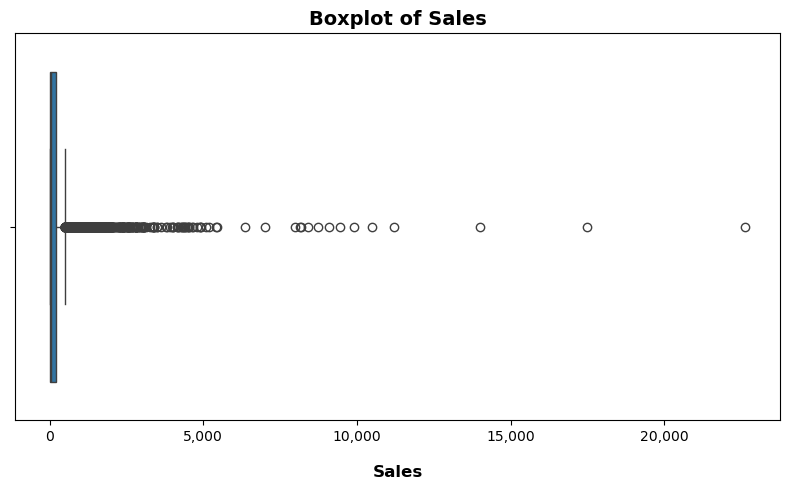

In [19]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x=df['Sales']
)

plt.title(
    'Boxplot of Sales',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Sales',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Format angka ribuan
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

plt.tight_layout()

plt.show()

## Sales Outlier Analysis

- Mayoritas transaksi memiliki nilai sales yang relatif rendah.
- Terdapat beberapa transaksi dengan nilai sales sangat tinggi hingga mencapai **22,638**, jauh di atas transaksi normal.
- Boxplot menunjukkan banyak outlier di sisi kanan sehingga distribusi sales cenderung **right-skewed**.
- Outlier tidak dihapus karena kemungkinan merepresentasikan transaksi bernilai besar (high-value transactions), bukan kesalahan data.

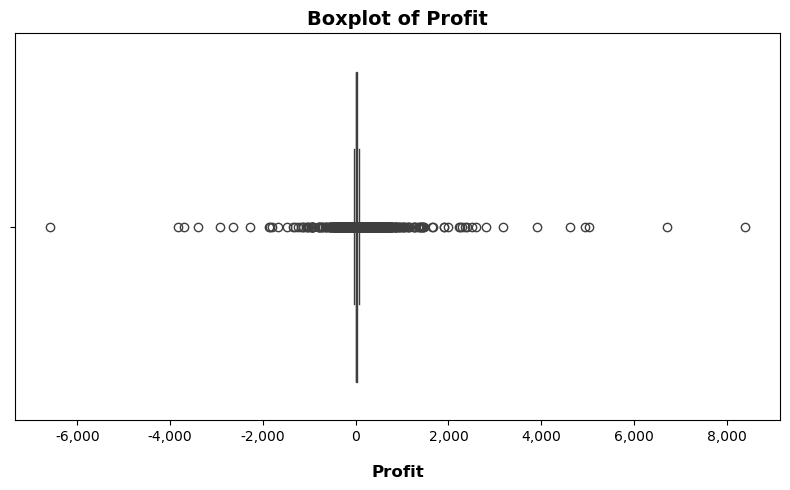

In [20]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x=df['Profit']
)

plt.title(
    'Boxplot of Profit',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Format angka ribuan
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

plt.tight_layout()

plt.show()

## Profit Outlier Analysis

- Profit memiliki rentang nilai yang sangat lebar, mulai dari sekitar **-6,600** hingga **8,400**.
- Terdapat outlier di kedua sisi, baik profit negatif maupun profit positif.
- Outlier negatif menunjukkan adanya transaksi yang menghasilkan kerugian besar.
- Outlier positif menunjukkan adanya transaksi dengan keuntungan yang sangat tinggi.
- Sebagian besar transaksi terkonsentrasi di sekitar nilai profit kecil dan dekat titik **0**, sehingga distribusi profit terlihat tidak merata.
- Keberadaan outlier perlu diperhatikan karena dapat memengaruhi rata-rata profit dan analisis profitabilitas perusahaan.

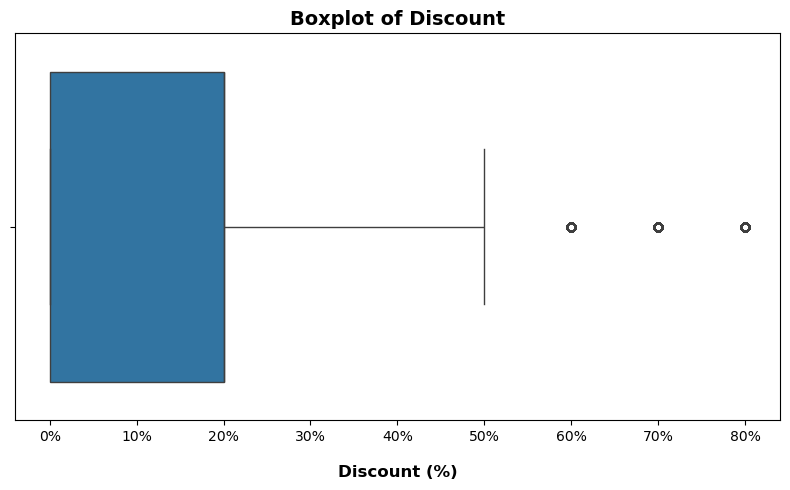

In [21]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x=df['Discount Pct']
)

plt.title(
    'Boxplot of Discount',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Discount (%)',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Tambahkan simbol %
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:.0f}%'
    )
)

plt.tight_layout()

plt.show()

## Discount Outlier Analysis

- Mayoritas transaksi memiliki discount pada rentang **0%–20%**.
- Median discount berada di sekitar **20%**, menunjukkan sebagian besar transaksi menggunakan diskon rendah.
- Nilai discount tertinggi mencapai **80%**.
- Terdapat outlier pada discount **60%, 70%, dan 80%**, yang menunjukkan hanya sedikit transaksi menggunakan diskon sangat tinggi.
- Distribusi discount cenderung terkonsentrasi pada diskon rendah, sedangkan diskon tinggi relatif jarang digunakan.
- Discount tinggi perlu diperhatikan karena berpotensi menurunkan profit dan profit margin perusahaan.

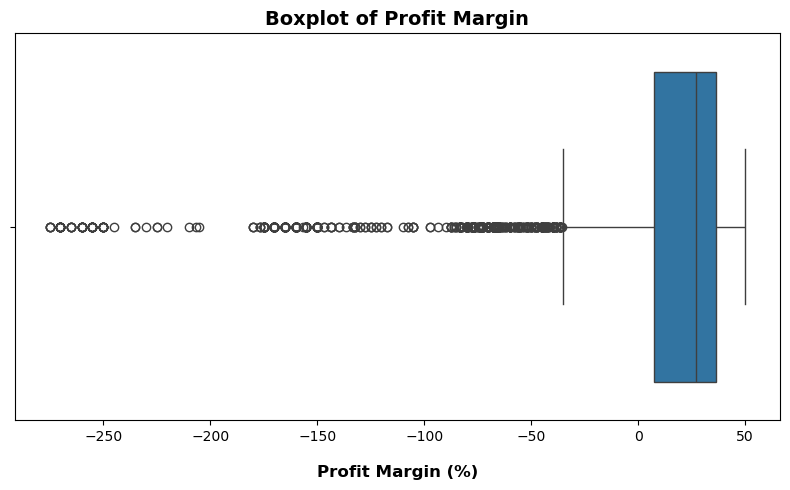

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Profit Margin Pct'],
)

plt.title(
    'Boxplot of Profit Margin',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Profit Margin (%)',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.tight_layout()

plt.show()

## Profit Margin Outlier Analysis

- Mayoritas transaksi memiliki profit margin positif pada rentang sekitar **0%–40%**.
- Median profit margin berada di sekitar **25%–30%**, menunjukkan sebagian besar transaksi masih menghasilkan keuntungan.
- Terdapat banyak outlier negatif dengan profit margin yang sangat rendah hingga sekitar **-275%**.
- Profit margin negatif menunjukkan adanya transaksi yang mengalami kerugian, bahkan kerugian lebih besar dibanding nilai penjualannya.
- Distribusi profit margin cenderung tidak simetris karena terdapat banyak nilai ekstrem di sisi negatif.
- Outlier negatif perlu diperhatikan karena dapat mengindikasikan transaksi dengan discount terlalu tinggi, biaya besar, atau strategi pricing yang kurang optimal.

Secara keseluruhan, hasil pengecekan boxplot menunjukkan adanya nilai ekstrem pada Sales, Profit, Discount, dan Profit Margin. Namun, outlier tersebut tidak dihapus karena masih memiliki makna bisnis. Nilai sales dan profit yang sangat tinggi dapat menunjukkan transaksi besar, sedangkan profit dan profit margin negatif dapat menunjukkan transaksi yang merugikan perusahaan. Oleh karena itu, outlier tetap dipertahankan agar analisis dapat menangkap kondisi bisnis secara lebih lengkap.

## 4.4 Cleaning Summary

Setelah proses data cleaning dilakukan, dataset siap digunakan untuk tahap analisis lebih lanjut. Beberapa tahapan cleaning yang telah dilakukan adalah:

1. Mengecek missing value pada seluruh kolom.
2. Mengecek data duplikat.
3. Mengubah kolom `Order Date` menjadi format datetime.
4. Membuat kolom tambahan `Year`, `Month`, `Month Name`, dan `Year-Month` untuk mendukung analisis berbasis waktu.
5. Melakukan standardisasi kolom kategorikal dengan menghapus spasi berlebih.
6. Membuat kolom `Profit Margin`, `Profit Margin Pct`, `Discount Pct` dan `Profit Status` untuk mendukung analisis profitabilitas.
7. Mengecek outlier pada variabel numerik utama.

Outlier tidak dihapus karena masih relevan dalam konteks bisnis. Nilai ekstrem pada sales dan profit dapat menunjukkan transaksi bernilai besar, sedangkan nilai profit negatif dapat menjadi indikator penting untuk mengidentifikasi area bisnis yang merugikan.

# 5. Exploratory Data Analysis

Pada tahap ini dilakukan exploratory data analysis untuk memahami performa bisnis perusahaan berdasarkan beberapa aspek utama, yaitu performa keseluruhan, tren waktu, region, segment, industry, product, serta hubungan antara discount dan profitabilitas. Tahap ini bertujuan untuk menjawab business questions yang telah ditentukan sebelumnya.

## 5.1 Overall Business Performance

Analisis awal dilakukan dengan melihat performa bisnis secara keseluruhan. Beberapa metrik yang digunakan adalah total sales, total profit, jumlah order, jumlah customer, total quantity, rata-rata discount, dan rata-rata profit margin.

Metrik ini penting untuk memberikan gambaran umum mengenai kondisi bisnis perusahaan. Total sales menunjukkan nilai penjualan yang diperoleh, sedangkan total profit menunjukkan keuntungan yang dihasilkan. Selain itu, average discount dan average profit margin digunakan untuk melihat apakah strategi penjualan perusahaan sudah cukup efektif dalam menghasilkan profit.

In [23]:
# Overall business performance
overall_performance = pd.DataFrame({
    'Total Sales': [df['Sales'].sum()],
    'Total Profit': [df['Profit'].sum()],
    'Total Orders': [df['Order ID'].nunique()],
    'Total Customers': [df['Customer ID'].nunique()],
    'Total Quantity': [df['Quantity'].sum()],
    'Average Discount Pct': [df['Discount Pct'].mean()],
    'Average Profit Margin Pct': [df['Profit Margin Pct'].mean()]
})

overall_performance

,Total Sales,Total Profit,Total Orders,Total Customers,Total Quantity,Average Discount Pct,Average Profit Margin Pct
0,2297200.86,286397.02,5009,99,37873,15.62,12.03


In [24]:
overall_performance.T.rename(columns={0: 'Value'})

,Value
Total Sales,2297200.86
Total Profit,286397.02
Total Orders,5009.00
Total Customers,99.00
Total Quantity,37873.00
Average Discount Pct,15.62
Average Profit Margin Pct,12.03


## 5.2 Sales and Profit Trend by Year

Analisis tren tahunan dilakukan untuk melihat perkembangan sales dan profit perusahaan dari tahun ke tahun. Dengan membandingkan sales dan profit, perusahaan dapat memahami apakah peningkatan penjualan juga diikuti oleh peningkatan keuntungan.

Analisis ini penting karena sales yang tinggi tidak selalu menunjukkan performa bisnis yang baik apabila profit yang dihasilkan tidak meningkat secara sebanding. Jika sales meningkat tetapi profit margin menurun, maka perusahaan perlu mengevaluasi efisiensi strategi penjualan, termasuk kemungkinan pengaruh discount, produk dengan margin rendah, atau segmen pelanggan yang kurang menguntungkan.

In [25]:
# Yearly sales and profit trend
yearly_performance = df.groupby('Year').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum'
}).reset_index()

yearly_performance['Profit Margin Pct'] = (
    yearly_performance['Profit'] /
    yearly_performance['Sales'] * 100
).round(2)

# Tabel display (tidak mengubah data asli)
yearly_performance_display = yearly_performance.copy()

yearly_performance_display['Sales'] = yearly_performance_display['Sales'].apply(
    lambda x: f'{x:,.2f}'
)

yearly_performance_display['Profit'] = yearly_performance_display['Profit'].apply(
    lambda x: f'{x:,.2f}'
)

yearly_performance_display['Quantity'] = yearly_performance_display['Quantity'].apply(
    lambda x: f'{x:,.0f}'
)

yearly_performance_display['Profit Margin Pct'] = yearly_performance_display['Profit Margin Pct'].apply(
    lambda x: f'{x:.2f}%'
)

yearly_performance_display

,Year,Sales,Profit,Quantity,Profit Margin Pct
0,2020,"484,247.50","49,543.97","7,581",10.23%
1,2021,"470,532.51","61,618.60","7,979",13.10%
2,2022,"608,473.83","81,726.93","9,810",13.43%
3,2023,"733,947.02","93,507.51","12,503",12.74%


## Yearly Performance Analysis

- Sales meningkat dari **484,247 (2020)** menjadi **733,947 (2023)**.
- Profit juga naik dari **49,544** menjadi **93,508**.
- Quantity meningkat dari **7,581** menjadi **12,503** unit.
- Profit Margin naik hingga **13.43% (2022)** lalu sedikit turun menjadi **12.74% (2023)**.
- Secara keseluruhan, performa bisnis menunjukkan tren pertumbuhan yang positif.

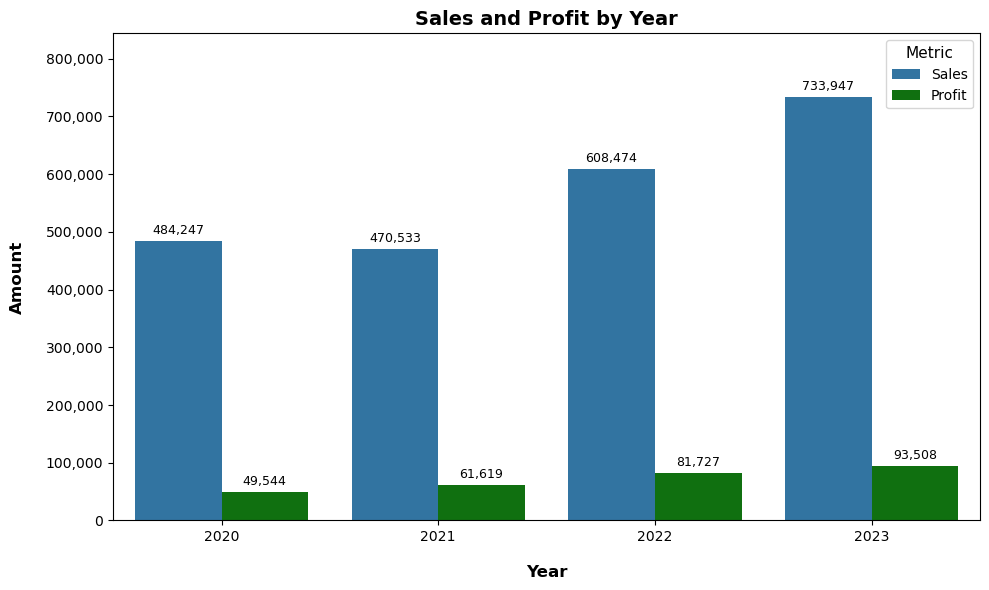

In [26]:
import matplotlib.ticker as ticker

# Ubah data dari wide ke long format
yearly_sales_profit = yearly_performance.melt(
    id_vars='Year',
    value_vars=['Sales', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=yearly_sales_profit,
    x='Year',
    y='Amount',
    hue='Metric',
    palette=['C0', 'green']
)

plt.title(
    'Sales and Profit by Year',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Year',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Amount',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.legend(
    title='Metric',
    title_fontsize=11,
    fontsize=10
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{v:,.0f}'
            for v in container.datavalues
        ],
        padding=3,
        fontsize=9
    )

plt.ylim(
    0,
    yearly_sales_profit['Amount'].max()*1.15
)
plt.savefig('sales_profit_by_year.png', dpi=300, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()

## Sales and Profit by Year Insight

- Sales dan profit menunjukkan tren meningkat dari tahun ke tahun.
- Tahun **2023** mencatat performa tertinggi dengan sales **733,947** dan profit **93,508**.
- Setelah sedikit menurun pada 2021, pertumbuhan meningkat cukup signifikan pada 2022–2023.
- Secara umum, perusahaan menunjukkan pertumbuhan bisnis yang positif.

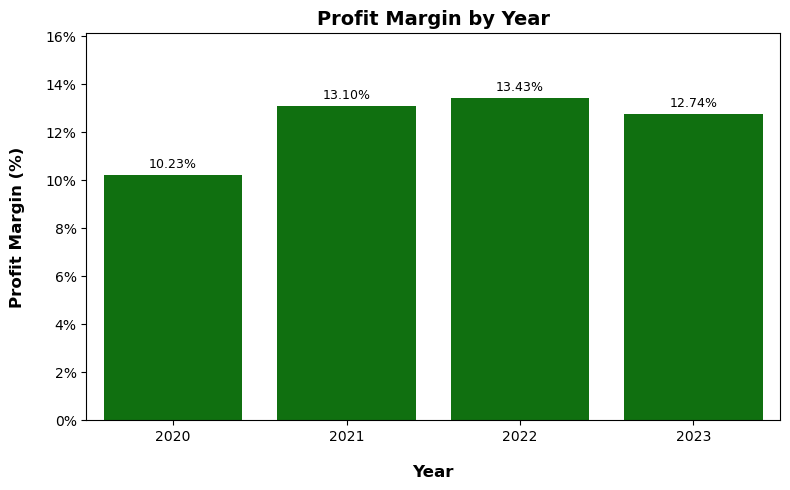

In [27]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=yearly_performance,
    x='Year',
    y='Profit Margin Pct',
    color='green'
)

plt.title(
    'Profit Margin by Year',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Year',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Profit Margin (%)',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%')
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.2f}%' for v in container.datavalues],
        padding=3,
        fontsize=9
    )

plt.ylim(
    0,
    yearly_performance['Profit Margin Pct'].max() * 1.20
)

plt.tight_layout()
plt.show()

## 5.3 Monthly Sales and Profit Trend  

Analisis bulanan dilakukan untuk melihat pola performa bisnis secara lebih detail. Tren bulanan dapat membantu mengidentifikasi periode dengan sales dan profit tertinggi maupun terendah.

Jika terdapat bulan dengan sales tinggi tetapi profit rendah, maka kondisi tersebut perlu dianalisis lebih lanjut karena dapat menunjukkan adanya transaksi dengan discount tinggi, produk dengan margin rendah, atau peningkatan transaksi yang kurang menguntungkan. Sebaliknya, bulan dengan profit tinggi dapat menjadi acuan untuk memahami pola transaksi yang lebih efektif bagi perusahaan.

In [28]:
# Monthly sales and profit trend
monthly_performance = df.groupby('Year-Month').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

monthly_performance['Profit Margin Pct'] = (
    monthly_performance['Profit'] / monthly_performance['Sales'] * 100
).round(2)

monthly_performance.head()

,Year-Month,Sales,Profit,Profit Margin Pct
0,2020-01,13946.23,2446.77,17.54
1,2020-02,4810.56,865.73,18.00
2,2020-03,55691.01,498.73,0.90
3,2020-04,28295.35,3488.84,12.33
4,2020-05,23648.29,2738.71,11.58


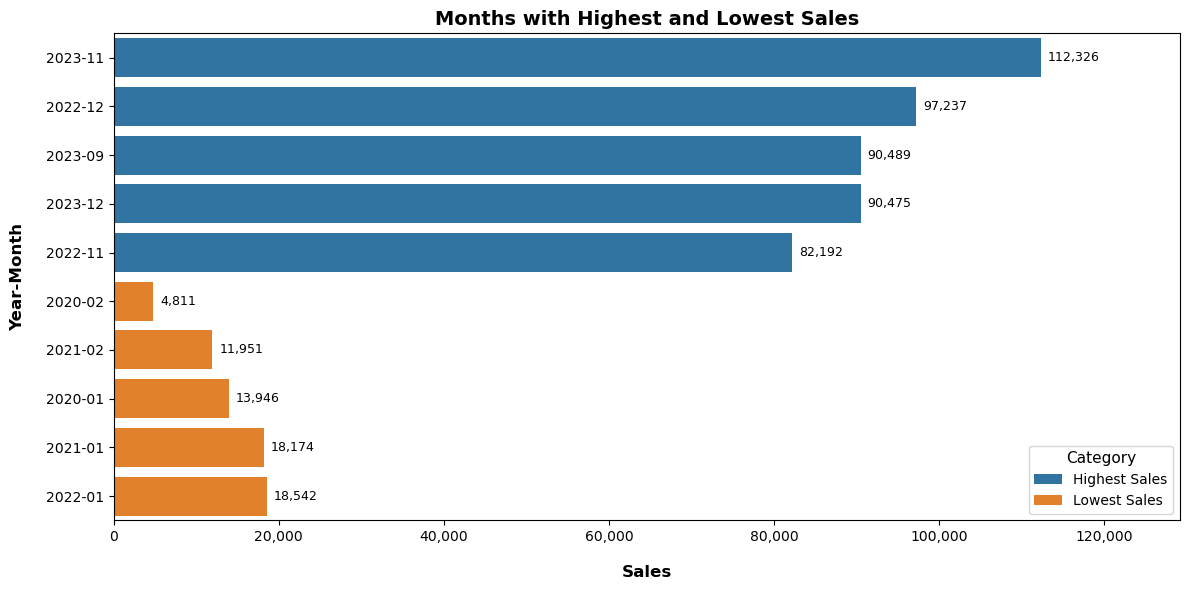

In [29]:
import matplotlib.ticker as ticker

top_5_sales = monthly_performance.sort_values(
    by='Sales',
    ascending=False
).head(5).copy()

bottom_5_sales = monthly_performance.sort_values(
    by='Sales',
    ascending=True
).head(5).copy()

top_5_sales['Category'] = 'Highest Sales'
bottom_5_sales['Category'] = 'Lowest Sales'

highest_lowest_sales = pd.concat([
    top_5_sales,
    bottom_5_sales
])

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=highest_lowest_sales,
    x='Sales',
    y='Year-Month',
    hue='Category'
)

plt.title(
    'Months with Highest and Lowest Sales',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Sales',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Year-Month',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.legend(
    title='Category',
    title_fontsize=11,
    fontsize=10
)

# format angka ribuan
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

# label angka (tidak bold)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{v:,.0f}'
            for v in container.datavalues
        ],
        padding=5,
        fontsize=9
    )

max_sales = highest_lowest_sales['Sales'].max()

plt.xlim(
    0,
    max_sales*1.15
)

plt.tight_layout()

plt.show()

## Highest and Lowest Sales Insight

- Penjualan tertinggi terjadi pada **November 2023** dengan total sales sebesar **112,326**.
- Sebagian besar bulan dengan sales tertinggi terjadi pada **tahun 2023**, menunjukkan peningkatan performa pada periode akhir.
- Sales terendah terjadi pada **Februari 2020** dengan nilai **4,811**.
- Terdapat perbedaan yang cukup besar antara bulan dengan sales tertinggi dan terendah, menunjukkan adanya fluktuasi penjualan antar periode.

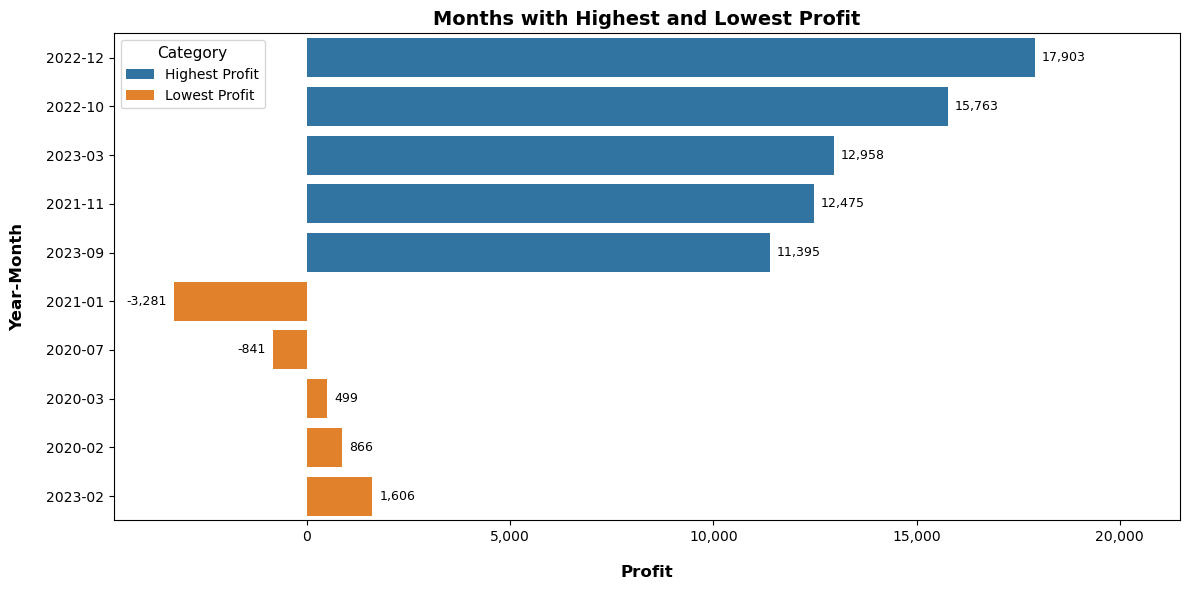

In [30]:
import matplotlib.ticker as ticker

top_5_profit = monthly_performance.sort_values(
    by='Profit',
    ascending=False
).head(5).copy()

bottom_5_profit = monthly_performance.sort_values(
    by='Profit',
    ascending=True
).head(5).copy()

top_5_profit['Category']='Highest Profit'
bottom_5_profit['Category']='Lowest Profit'

highest_lowest_profit=pd.concat([
    top_5_profit,
    bottom_5_profit
])

plt.figure(figsize=(12,6))

ax=sns.barplot(
    data=highest_lowest_profit,
    x='Profit',
    y='Year-Month',
    hue='Category',
)

plt.title(
    'Months with Highest and Lowest Profit',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Year-Month',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.legend(
    title='Category',
    title_fontsize=11,
    fontsize=10
)

# format angka ribuan
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

# label angka (tidak bold)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{v:,.0f}'
            for v in container.datavalues
        ],
        padding=5,
        fontsize=9
    )

min_profit=highest_lowest_profit['Profit'].min()
max_profit=highest_lowest_profit['Profit'].max()

plt.xlim(
    min_profit*1.45,
    max_profit*1.20
)

plt.tight_layout()

plt.show()

## Highest and Lowest Profit Insight

- Profit tertinggi terjadi pada **Desember 2022** dengan nilai **17,903**.
- Sebagian besar bulan dengan profit tertinggi terjadi pada **akhir 2022 hingga 2023**, menunjukkan peningkatan profitabilitas perusahaan.
- Profit terendah terjadi pada **Januari 2021** dengan kerugian sebesar **-3,281**.
- Terdapat perbedaan yang cukup besar antara profit tertinggi dan terendah, menunjukkan fluktuasi profit yang signifikan antar periode.

## 5.4 Performance by Region

Analisis berdasarkan region digunakan untuk melihat wilayah mana yang memberikan kontribusi sales dan profit terbesar bagi perusahaan. Analisis ini penting karena wilayah dengan sales tinggi belum tentu memiliki profit yang tinggi pula.

Dengan membandingkan sales, profit, dan profit margin antar region, perusahaan dapat mengetahui wilayah mana yang perlu diprioritaskan untuk ekspansi dan wilayah mana yang perlu dievaluasi strategi penjualannya. Region dengan profit margin rendah perlu dianalisis lebih lanjut, terutama jika wilayah tersebut memiliki sales tinggi tetapi tidak menghasilkan profit yang sebanding.

In [31]:
region_performance = df.groupby('Region').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

region_performance['Profit Margin Pct'] = (
    region_performance['Profit'] /
    region_performance['Sales'] *100
).round(2)

region_performance = region_performance.sort_values(
    by='Profit',
    ascending=False
)

# Tabel display (aman, tidak mengubah data asli)
region_performance_display = region_performance.copy()

region_performance_display['Sales'] = region_performance_display['Sales'].apply(
    lambda x: f'{x:,.2f}'
)

region_performance_display['Profit'] = region_performance_display['Profit'].apply(
    lambda x: f'{x:,.2f}'
)

region_performance_display['Profit Margin Pct'] = region_performance_display['Profit Margin Pct'].apply(
    lambda x: f'{x:.2f}%'
)

region_performance_display

,Region,Sales,Profit,Profit Margin Pct
2,EMEA,"1,043,887.02","147,456.05",14.13%
0,AMER,"837,849.60","127,426.99",15.21%
1,APJ,"415,464.24","11,513.99",2.77%


## Regional Performance Insight

- **EMEA** memiliki total sales tertinggi (**1,043,887**) dan profit tertinggi (**147,456**).
- **AMER** memiliki **Profit Margin tertinggi (15.21%)**, menunjukkan efisiensi keuntungan yang lebih baik dibanding region lain.
- **APJ** memiliki profit margin paling rendah (**2.77%**), meskipun tetap menghasilkan profit positif.
- Hal ini menunjukkan bahwa region dengan sales terbesar tidak selalu memiliki profitabilitas terbaik.

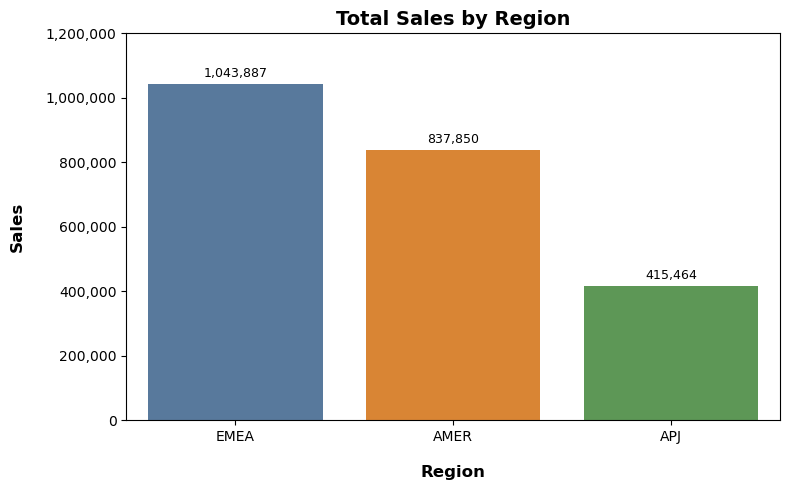

In [32]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=region_performance,
    x='Region',
    y='Sales',
    palette=['#4C78A8', '#F58518', '#54A24B']
)

plt.title(
    'Total Sales by Region',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Region',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Sales',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Hilangkan format 1e6
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'{x:,.0f}'
    )
)

# Tambahkan label angka
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        padding=3,
        fontsize=9
    )

plt.ylim(
    0,
    region_performance['Sales'].max()*1.15
)

plt.tight_layout()

plt.show()

## Total Sales by Region Insight

- **EMEA** mencatat total sales tertinggi sebesar **1,043,887**.
- **AMER** berada di posisi kedua dengan total sales **837,850**.
- **APJ** memiliki sales terendah sebesar **415,464**.
- Perbedaan sales antar region cukup besar, menunjukkan kontribusi penjualan yang tidak merata di setiap wilayah.

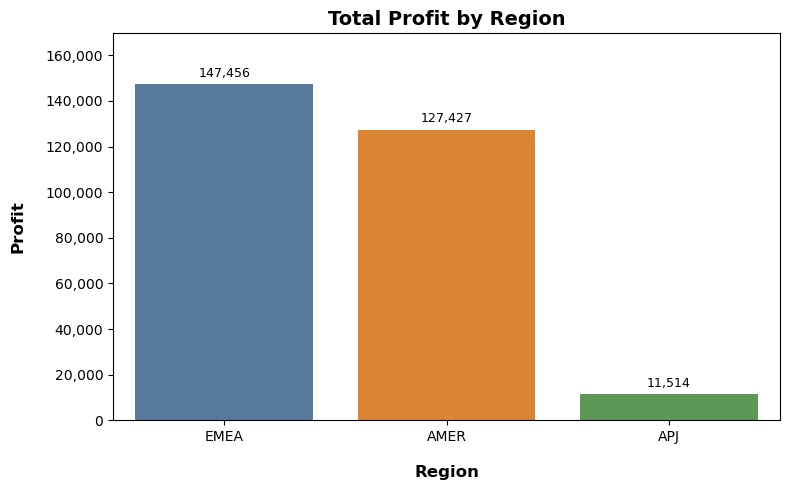

In [33]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=region_performance.sort_values(
        by='Profit',
        ascending=False
    ),
    x='Region',
    y='Profit',
    palette=['#4C78A8','#F58518','#54A24B']
)

plt.title(
    'Total Profit by Region',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Region',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Hilangkan format 1e6
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

# Tambah angka (tidak bold)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{v:,.0f}'
            for v in container.datavalues
        ],
        padding=3,
        fontsize=9
    )

plt.ylim(
    0,
    region_performance['Profit'].max()*1.15
)

plt.tight_layout()
plt.show()

## Total Profit by Region Insight

- **EMEA** menghasilkan profit tertinggi sebesar **147,456**, diikuti **AMER** sebesar **127,427**.
- Meskipun sales AMER cukup tinggi, profitnya masih berada di bawah EMEA.
- **APJ** memiliki profit jauh lebih rendah (**11,514**) dibanding region lain.
- Terdapat perbedaan profit yang cukup signifikan antar region, menunjukkan kontribusi keuntungan yang tidak merata.

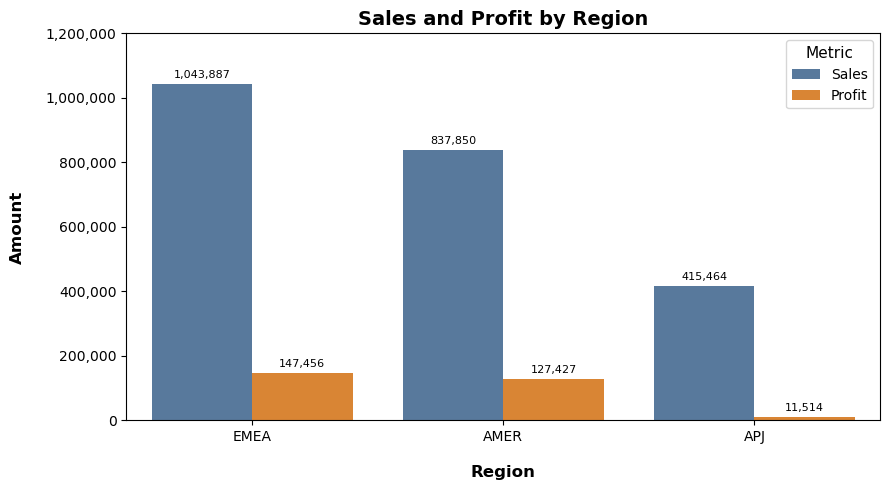

In [34]:
import matplotlib.ticker as ticker

# Ubah data ke format long
region_sales_profit = region_performance.melt(
    id_vars='Region',
    value_vars=['Sales','Profit'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=region_sales_profit,
    x='Region',
    y='Value',
    hue='Metric',
    palette=['#4C78A8','#F58518']
)

plt.title(
    'Sales and Profit by Region',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Region',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Amount',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Hilangkan format 1e6
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

# Tambah angka
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{v:,.0f}'
            for v in container.datavalues
        ],
        padding=3,
        fontsize=8
    )

plt.legend(
    title='Metric',
    title_fontsize=11,
    fontsize=10
)

plt.ylim(
    0,
    region_sales_profit['Value'].max()*1.15
)

plt.tight_layout()

plt.show()

## Sales and Profit by Region Insight

- **EMEA** menunjukkan performa terbaik dengan sales (**1,043,887**) dan profit (**147,456**) tertinggi.
- **AMER** memiliki sales dan profit yang cukup tinggi, tetapi masih berada di bawah EMEA.
- **APJ** menghasilkan sales yang cukup besar (**415,464**), namun profitnya hanya **11,514**, jauh lebih rendah dibanding region lain.
- Hal ini menunjukkan bahwa sales yang tinggi tidak selalu menghasilkan profit yang tinggi, sehingga efisiensi dan profit margin juga perlu diperhatikan.

## 5.5 Performance by Segment

Analisis berdasarkan segment dilakukan untuk mengetahui jenis pelanggan yang paling berkontribusi terhadap sales dan profit perusahaan. Dalam bisnis B2B, setiap segment pelanggan dapat memiliki karakteristik pembelian yang berbeda, baik dari sisi jumlah transaksi, nilai sales, maupun profit margin.

Segment dengan profit tinggi dapat menjadi prioritas utama dalam strategi penjualan. Sebaliknya, segment dengan profit rendah atau profit margin rendah perlu dievaluasi, terutama jika segment tersebut banyak menggunakan discount tetapi tidak memberikan profit yang optimal.

In [35]:
# Performance by segment
segment_performance = df.groupby('Segment').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

segment_performance['Profit Margin'] = (
    segment_performance['Profit'] /
    segment_performance['Sales']
)

segment_performance['Profit Margin Pct'] = (
    segment_performance['Profit Margin'] * 100
).round(2)

segment_performance = segment_performance.sort_values(
    by='Profit',
    ascending=False
)

# Tabel display (tidak mengubah data asli)
segment_performance_display = segment_performance.copy()

segment_performance_display['Sales'] = segment_performance_display['Sales'].apply(
    lambda x: f'{x:,.2f}'
)

segment_performance_display['Profit'] = segment_performance_display['Profit'].apply(
    lambda x: f'{x:,.2f}'
)

segment_performance_display['Profit Margin Pct'] = segment_performance_display['Profit Margin Pct'].apply(
    lambda x: f'{x:.2f}%'
)

# Hapus kolom Profit Margin desimal agar tabel lebih bersih
segment_performance_display = segment_performance_display.drop(
    columns='Profit Margin'
)

segment_performance_display

,Segment,Sales,Profit,Profit Margin Pct
1,SMB,"1,161,401.34","134,119.21",11.55%
2,Strategic,"706,146.37","91,979.13",13.03%
0,Enterprise,"429,653.15","60,298.68",14.03%


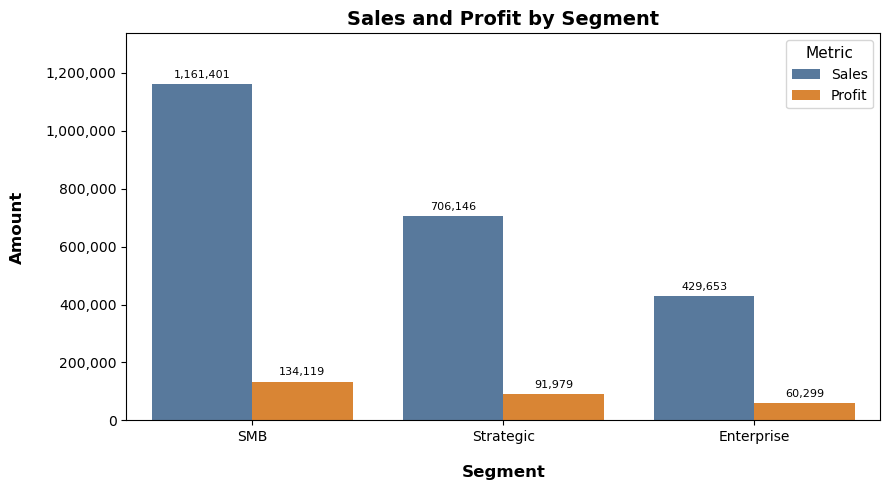

In [36]:
import matplotlib.ticker as ticker

# Ubah format data
segment_sales_profit = segment_performance.melt(
    id_vars='Segment',
    value_vars=['Sales','Profit'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=segment_sales_profit,
    x='Segment',
    y='Value',
    hue='Metric',
    palette=['#4C78A8','#F58518']
)

plt.title(
    'Sales and Profit by Segment',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Segment',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Amount',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Hilangkan format 1e6
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x,pos: f'{x:,.0f}')
)

# Angka di atas bar (TIDAK bold)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        padding=3,
        fontsize=8
    )

plt.legend(
    title='Metric',
    title_fontsize=11,
    fontsize=10
)

plt.ylim(
    0,
    segment_sales_profit['Value'].max()*1.15
)

plt.tight_layout()
plt.show()

## Sales and Profit by Segment Insight

- **SMB** memberikan kontribusi terbesar dengan sales (**1,161,401**) dan profit (**134,119**) tertinggi.
- **Strategic** berada di posisi kedua untuk sales maupun profit.
- **Enterprise** memiliki sales dan profit terendah dibanding segment lainnya.
- Pola ini menunjukkan bahwa **SMB menjadi segmen utama yang paling berkontribusi terhadap pertumbuhan bisnis perusahaan.**

## 5.6 Performance by Industry

Analisis berdasarkan industry digunakan untuk mengetahui sektor pelanggan yang paling menguntungkan bagi perusahaan. Setiap industry dapat memiliki kebutuhan, pola pembelian, dan sensitivitas terhadap harga yang berbeda.

Industry dengan profit tinggi dapat menjadi target prioritas dalam strategi sales dan marketing. Sementara itu, industry dengan profit rendah atau negatif perlu dianalisis lebih lanjut untuk mengetahui apakah rendahnya profit disebabkan oleh discount tinggi, jumlah transaksi rendah, atau produk yang kurang menguntungkan.

In [37]:
# Performance by industry
industry_performance = df.groupby('Industry').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Profit Margin (%)
industry_performance['Profit Margin Pct'] = (
    industry_performance['Profit'] /
    industry_performance['Sales'] * 100
).round(2)

# Urutkan berdasarkan profit tertinggi
industry_performance = industry_performance.sort_values(
    by='Profit',
    ascending=False
)

# Tabel display (tidak mengubah data asli)
industry_performance_display = industry_performance.copy()

industry_performance_display['Sales'] = (
    industry_performance_display['Sales']
    .apply(lambda x: f'{x:,.2f}')
)

industry_performance_display['Profit'] = (
    industry_performance_display['Profit']
    .apply(lambda x: f'{x:,.2f}')
)

industry_performance_display['Profit Margin Pct'] = (
    industry_performance_display['Profit Margin Pct']
    .apply(lambda x: f'{x:.2f}%')
)

# Nomor urut rapi
industry_performance_display = (
    industry_performance_display
    .reset_index(drop=True)
)

industry_performance_display.index += 1
industry_performance_display.index.name='No'

industry_performance_display

,Industry,Sales,Profit,Profit Margin Pct
No,,,,
1,Finance,"474,150.48","50,348.97",10.62%
2,Energy,"304,644.14","45,282.31",14.86%
3,Manufacturing,"295,192.38","38,413.11",13.01%
4,Consumer Products,"224,044.14","37,018.01",16.52%
5,Healthcare,"273,183.29","31,969.09",11.70%
6,Retail,"223,072.07","30,207.82",13.54%
7,Tech,"263,169.03","24,615.04",9.35%
8,Communications,"120,962.24","13,976.34",11.55%
9,Transportation,"90,191.33","7,402.70",8.21%


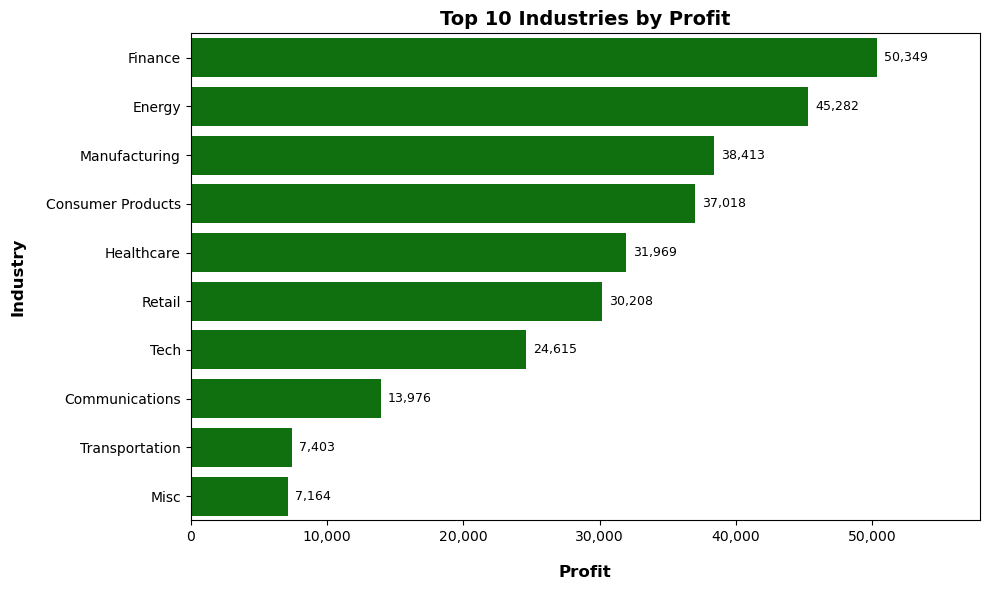

In [38]:
import matplotlib.ticker as ticker

top_industry_profit = industry_performance.sort_values(
    by='Profit',
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_industry_profit,
    y='Industry',
    x='Profit',
    color='green'   # WARNA HIJAU
)

plt.title(
    'Top 10 Industries by Profit',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Industry',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Format angka ribuan di sumbu X
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

# Tambahkan angka di ujung bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        padding=5,
        fontsize=9
    )

# Tambahkan ruang kanan agar label tidak kepotong
plt.xlim(
    0,
    top_industry_profit['Profit'].max() * 1.15
)

plt.tight_layout()

plt.show()

## Industry Profit Insight

- **Finance** menghasilkan profit tertinggi sebesar **50,349**, diikuti **Energy** (**45,282**) dan **Manufacturing** (**38,413**).
- Sebagian besar profit terkonsentrasi pada beberapa industri utama, terutama **Finance** dan **Energy**.
- **Transportation** dan **Misc** memiliki profit paling rendah, masing-masing hanya sekitar **7,403** dan **7,164**.
- Hal ini menunjukkan bahwa kontribusi profit antar industri tidak merata dan terdapat industri yang jauh lebih menguntungkan dibanding lainnya.

## 5.7 Performance by Product

Analisis produk dilakukan untuk mengetahui produk mana yang memberikan kontribusi sales dan profit terbesar maupun terendah. Dalam bisnis SaaS, analisis produk penting karena setiap produk dapat memiliki tingkat permintaan, nilai penjualan, dan profit margin yang berbeda.

Produk dengan profit tinggi dapat menjadi fokus utama dalam strategi penjualan. Sebaliknya, produk dengan profit rendah atau negatif perlu dievaluasi, baik dari sisi pricing, strategi discount, maupun target pelanggan yang membeli produk tersebut.

In [39]:
# Performance by product
product_performance = df.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Membuat profit margin dalam bentuk persen
product_performance['Profit Margin Pct'] = (
    product_performance['Profit'] / product_performance['Sales'] * 100
).round(2)

# Mengurutkan berdasarkan profit tertinggi
product_performance = product_performance.sort_values(
    by='Profit',
    ascending=False
)

# Menampilkan data asli hasil agregasi
product_performance

# Membuat salinan tabel agar tidak mengubah product_performance asli
product_performance_table = product_performance.copy()

# Format angka agar lebih mudah dibaca
product_performance_table['Sales'] = product_performance_table['Sales'].apply(
    lambda x: f'{x:,.2f}'
)

product_performance_table['Profit'] = product_performance_table['Profit'].apply(
    lambda x: f'{x:,.2f}'
)

product_performance_table['Quantity'] = product_performance_table['Quantity'].apply(
    lambda x: f'{x:,.0f}'
)

product_performance_table['Profit Margin Pct'] = product_performance_table['Profit Margin Pct'].apply(
    lambda x: f'{x:.2f}%'
)

# Reset index agar nomor urut menjadi 1, 2, 3, ...
product_performance_table = product_performance_table.reset_index(drop=True)
product_performance_table.index = product_performance_table.index + 1
product_performance_table.index.name = 'No'

product_performance_table

,Product,Sales,Profit,Quantity,Profit Margin Pct
No,,,,,
1,Alchemy,"149,528.03","55,617.82",234,37.20%
2,Site Analytics,"330,007.05","44,515.73","3,289",13.49%
3,Data Smasher,"167,380.32","41,936.64","2,976",25.05%
4,Support,"125,152.74","32,864.47","5,825",26.26%
5,FinanceHub,"340,935.41","32,136.42","3,756",9.43%
6,Marketing Suite - Gold,"223,843.61","21,278.83","3,158",9.51%
7,OneView,"107,532.16","18,138.01","1,729",16.87%
8,SaaS Connector Pack,"91,705.16","13,059.14","3,563",14.24%
9,ContactMatcher,"410,378.27","12,496.28","7,215",3.05%


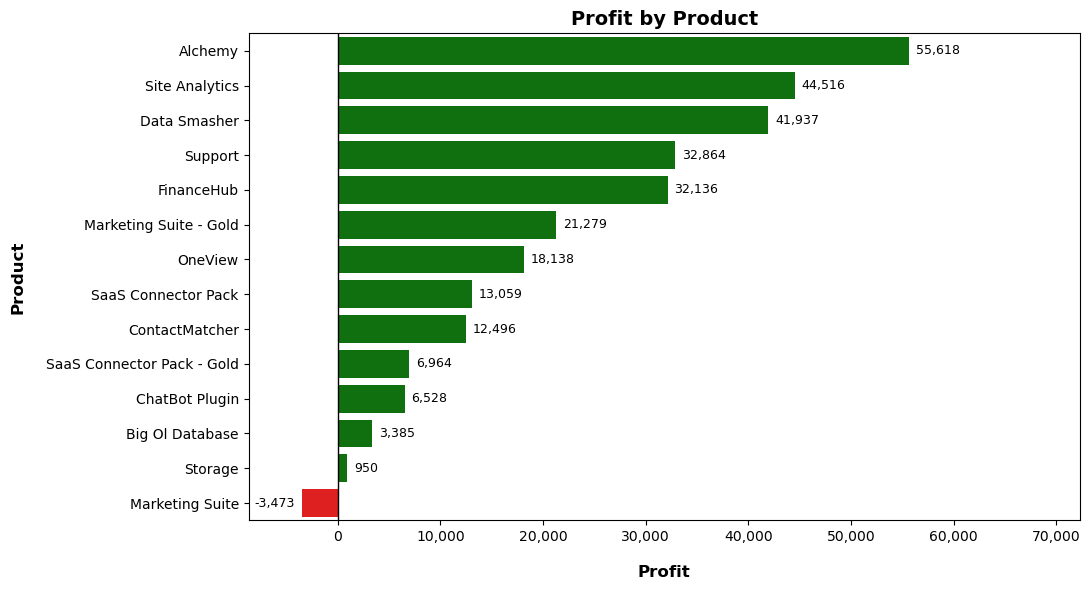

In [40]:
import matplotlib.ticker as ticker

# Buat warna berdasarkan nilai profit
colors = [
    'green' if x >= 0 else 'red'
    for x in product_performance['Profit']
]

plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=product_performance,
    y='Product',
    x='Profit',
    palette=colors
)

plt.title(
    'Profit by Product',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Product',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Format angka ribuan
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

# Garis 0 agar profit negatif dan positif mudah dibedakan
plt.axvline(
    0,
    color='black',
    linewidth=1
)

# Tambahkan angka di ujung bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        padding=5,
        fontsize=9
    )

# Atur batas X agar label dan bagian minus tetap terlihat
min_profit = product_performance['Profit'].min()
max_profit = product_performance['Profit'].max()

plt.xlim(
    min_profit * 2.50 if min_profit < 0 else -max_profit * 0.05,
    max_profit * 1.30
)

plt.tight_layout()
plt.show()

In [41]:
product_profit_table = product_performance[['Product', 'Profit']].copy()

product_profit_table = product_profit_table.sort_values(
    by='Profit',
    ascending=False
)

product_profit_table['Profit'] = product_profit_table['Profit'].apply(
    lambda x: f'{x:,.2f}'
)

product_profit_table = product_profit_table.reset_index(drop=True)
product_profit_table.index = product_profit_table.index + 1
product_profit_table.index.name = 'No'

product_profit_table

,Product,Profit
No,,
1,Alchemy,"55,617.82"
2,Site Analytics,"44,515.73"
3,Data Smasher,"41,936.64"
4,Support,"32,864.47"
5,FinanceHub,"32,136.42"
6,Marketing Suite - Gold,"21,278.83"
7,OneView,"18,138.01"
8,SaaS Connector Pack,"13,059.14"
9,ContactMatcher,"12,496.28"


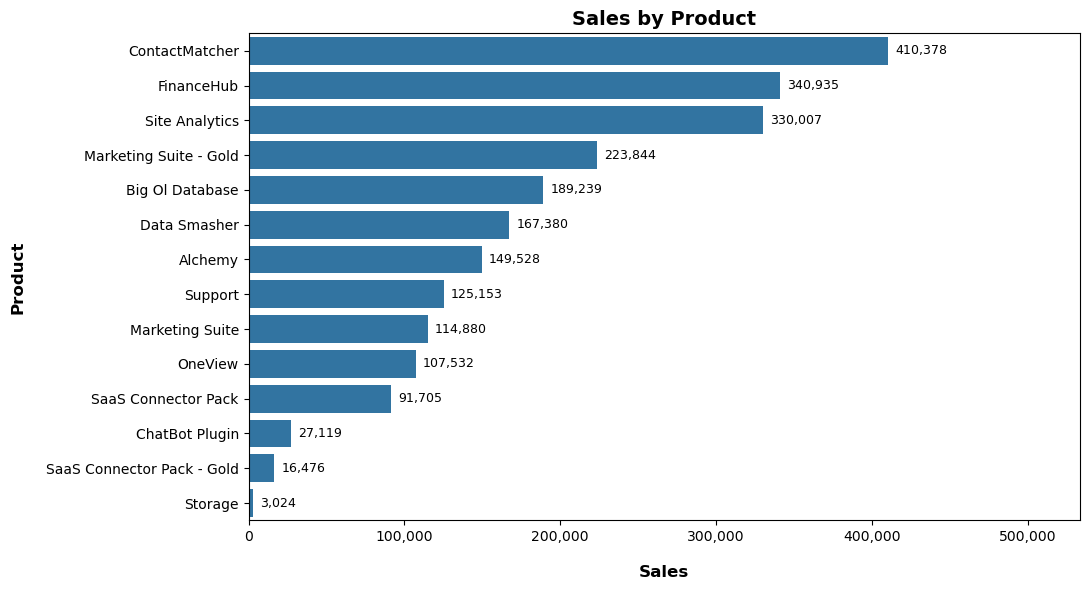

In [42]:
import matplotlib.ticker as ticker

product_sales = product_performance.sort_values(
    by='Sales',
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=product_sales,
    y='Product',
    x='Sales'
)

plt.title(
    'Sales by Product',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Sales',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Product',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Format angka ribuan di sumbu X
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

# Tambahkan angka di ujung bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        padding=5,
        fontsize=9
    )

# Tambahkan ruang kanan agar angka tidak kepotong
plt.xlim(
    0,
    product_sales['Sales'].max() * 1.30
)

plt.tight_layout()
plt.show()

## Product Sales Insight

- **ContactMatcher** mencatat sales tertinggi dibanding product lainnya.
- **FinanceHub** dan **Site Analytics** juga menunjukkan kontribusi sales yang besar.
- Meskipun **ContactMatcher** memiliki sales tertinggi, product dengan sales tinggi belum tentu menghasilkan profit tertinggi.
- **Storage** dan **SaaS Connector Pack - Gold** memiliki sales paling rendah dibanding product lain.
- Hal ini menunjukkan adanya perbedaan kontribusi penjualan yang cukup besar antar product.

In [43]:
product_sales_table = product_sales[['Product', 'Sales']].copy()

product_sales_table['Sales'] = product_sales_table['Sales'].apply(
    lambda x: f'{x:,.2f}'
)

product_sales_table = product_sales_table.reset_index(drop=True)
product_sales_table.index = product_sales_table.index + 1
product_sales_table.index.name = 'No'

product_sales_table

,Product,Sales
No,,
1,ContactMatcher,"410,378.27"
2,FinanceHub,"340,935.41"
3,Site Analytics,"330,007.05"
4,Marketing Suite - Gold,"223,843.61"
5,Big Ol Database,"189,238.63"
6,Data Smasher,"167,380.32"
7,Alchemy,"149,528.03"
8,Support,"125,152.74"
9,Marketing Suite,"114,880.00"


## 5.8 Discount and Profitability Analysis

Analisis discount dilakukan untuk melihat apakah pemberian discount berhubungan dengan profitabilitas perusahaan. Discount dapat menjadi strategi untuk meningkatkan penjualan, tetapi apabila diberikan terlalu tinggi, discount juga dapat menurunkan profit.

Melalui pengelompokan discount, perusahaan dapat melihat kategori discount mana yang masih menghasilkan profit dan kategori mana yang mulai menyebabkan kerugian. Analisis ini penting karena strategi discount seharusnya tidak hanya meningkatkan sales, tetapi juga tetap menjaga profitabilitas perusahaan.

In [44]:
# Membuat kategori discount
df['Discount Category'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8],
    labels=[
        'No Discount',
        'Low Discount',
        'Medium Discount',
        'High Discount',
        'Very High Discount'
    ]
)

# Analisis discount
discount_analysis = df.groupby('Discount Category').agg({
    'Row ID': 'count',
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit Margin Pct': 'mean'
}).reset_index()

discount_analysis.rename(
    columns={
        'Row ID': 'Transaction Count',
        'Profit Margin Pct': 'Avg Profit Margin Pct'
    },
    inplace=True
)

discount_analysis['Avg Profit Margin Pct'] = discount_analysis['Avg Profit Margin Pct'].round(2)

# Membuat tabel display agar data asli tetap aman
discount_analysis_display = discount_analysis.copy()

discount_analysis_display['Transaction Count'] = discount_analysis_display['Transaction Count'].apply(
    lambda x: f'{x:,.0f}'
)

discount_analysis_display['Sales'] = discount_analysis_display['Sales'].apply(
    lambda x: f'{x:,.2f}'
)

discount_analysis_display['Profit'] = discount_analysis_display['Profit'].apply(
    lambda x: f'{x:,.2f}'
)

discount_analysis_display['Avg Profit Margin Pct'] = discount_analysis_display['Avg Profit Margin Pct'].apply(
    lambda x: f'{x:.2f}%'
)

discount_analysis_display

,Discount Category,Transaction Count,Sales,Profit,Avg Profit Margin Pct
0,No Discount,"4,798","1,087,908.47","320,987.60",34.02%
1,Low Discount,"3,803","846,522.24","100,785.47",17.44%
2,Medium Discount,460,"234,137.90","-35,817.47",-16.69%
3,High Discount,215,"71,048.21","-28,944.19",-63.41%
4,Very High Discount,718,"57,584.04","-70,614.40",-122.52%


## Discount Category Explanation

Discount dalam dataset dikelompokkan menjadi lima kategori untuk memudahkan analisis profitabilitas berdasarkan tingkat diskon. Kategori tersebut terdiri dari:

- **No Discount**: transaksi tanpa diskon atau discount sebesar 0%.
- **Low Discount**: transaksi dengan discount lebih dari 0% hingga 20%.
- **Medium Discount**: transaksi dengan discount lebih dari 20% hingga 40%.
- **High Discount**: transaksi dengan discount lebih dari 40% hingga 60%.
- **Very High Discount**: transaksi dengan discount lebih dari 60% hingga 80%.

Pengelompokan ini digunakan untuk membandingkan apakah semakin tinggi tingkat discount berhubungan dengan penurunan profit dan profit margin perusahaan.

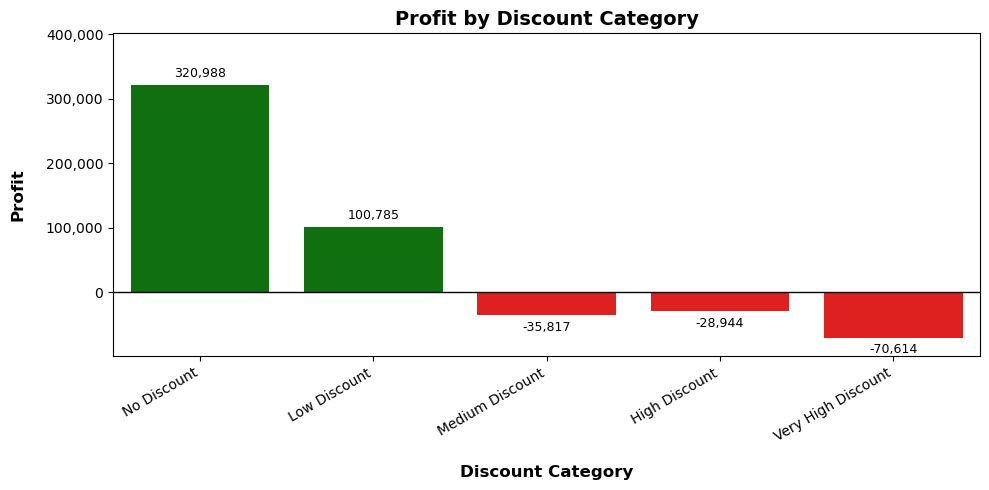

In [63]:
import matplotlib.ticker as ticker

# Warna berdasarkan nilai profit
colors = [
    'green' if x >= 0 else 'red'
    for x in discount_analysis['Profit']
]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=discount_analysis,
    x='Discount Category',
    y='Profit',
    palette=colors
)

plt.title(
    'Profit by Discount Category',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Discount Category',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.xticks(
    rotation=30,
    ha='right'
)

# Format angka ribuan
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'{x:,.0f}'
    )
)

# Tambahkan garis profit = 0
plt.axhline(
    0,
    color='black',
    linewidth=1
)

# Tambahkan label angka pada tiap bar
for container in ax.containers:
    labels = [f'{v:,.0f}' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        padding=4,
        fontsize=9
    )

# Atur limit agar label negatif tidak kepotong
min_profit = discount_analysis['Profit'].min()
max_profit = discount_analysis['Profit'].max()

plt.ylim(
    min_profit * 1.40 if min_profit < 0 else 0,
    max_profit * 1.25
)

plt.tight_layout()

plt.show()

## Profit by Discount Category Insight

- Transaksi **tanpa discount** menghasilkan profit tertinggi, lebih dari **300,000**.
- Profit masih positif pada **Low Discount**, tetapi nilainya turun cukup signifikan dibanding tanpa discount.
- Mulai dari **Medium Discount** hingga **Very High Discount**, profit berubah menjadi negatif.
- **Very High Discount** menghasilkan kerugian terbesar dibanding kategori lainnya.
- Hal ini menunjukkan bahwa semakin tinggi discount yang diberikan, semakin besar risiko penurunan profitabilitas.

In [46]:
discount_profit_table = discount_analysis[
    ['Discount Category', 'Profit']
].copy()

discount_profit_table['Profit'] = discount_profit_table['Profit'].apply(
    lambda x: f'{x:,.2f}'
)

discount_profit_table = discount_profit_table.reset_index(drop=True)
discount_profit_table.index = discount_profit_table.index + 1
discount_profit_table.index.name = 'No'

discount_profit_table

,Discount Category,Profit
No,,
1,No Discount,"320,987.60"
2,Low Discount,"100,785.47"
3,Medium Discount,"-35,817.47"
4,High Discount,"-28,944.19"
5,Very High Discount,"-70,614.40"


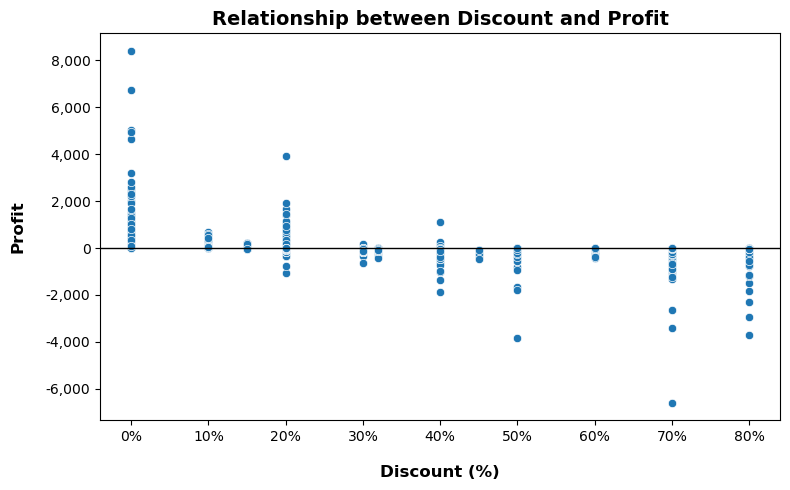

In [47]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8, 5))

ax = sns.scatterplot(
    data=df,
    x='Discount Pct',
    y='Profit'
)

plt.title(
    'Relationship between Discount and Profit',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Discount (%)',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%')
)

plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.tight_layout()
plt.show()

## Discount and Profit Relationship Insight

- Transaksi dengan **discount rendah (0%–20%)** cenderung memiliki variasi profit yang lebih tinggi dan banyak transaksi menghasilkan profit positif.
- Pada discount **40%–80%**, lebih banyak transaksi berada di bawah garis profit **0**, yang menunjukkan kerugian.
- Terdapat beberapa outlier dengan profit sangat tinggi dan sangat rendah pada beberapa tingkat discount.
- Grafik menunjukkan adanya **indikasi hubungan negatif** antara discount dan profit, di mana profit cenderung menurun saat discount meningkat.

## 5.9 Loss Transaction Analysis

Analisis transaksi loss dilakukan untuk memahami transaksi yang menghasilkan profit negatif. Tahap ini penting karena perusahaan tidak hanya perlu mengetahui sumber profit terbesar, tetapi juga perlu mengidentifikasi sumber kerugian.

Dengan melihat loss berdasarkan product dan segment, perusahaan dapat mengetahui area bisnis mana yang perlu dievaluasi. Jika suatu produk atau segmen memiliki jumlah transaksi loss yang tinggi, maka perusahaan perlu meninjau kembali strategi harga, discount, atau target market pada area tersebut.

In [48]:
# Memisahkan transaksi profit dan loss
loss_transactions = df[df['Profit'] < 0]
profit_transactions = df[df['Profit'] >= 0]

loss_summary = pd.DataFrame({
    'Total Transactions': [len(df)],
    'Profit Transactions': [len(profit_transactions)],
    'Loss Transactions': [len(loss_transactions)],
    'Loss Transaction Percentage': [len(loss_transactions) / len(df) * 100],
    'Total Loss': [loss_transactions['Profit'].sum()]
})

loss_summary

,Total Transactions,Profit Transactions,Loss Transactions,Loss Transaction Percentage,Total Loss
0,9994,8123,1871,18.72,-156131.29


## Loss Transaction Summary Insight

- Dari total **9,994 transaksi**, terdapat **1,871 transaksi loss** atau sekitar **18.72%** dari seluruh transaksi.
- Total kerugian dari transaksi loss mencapai sekitar **-156,131**.
- Meskipun mayoritas transaksi masih menghasilkan profit, proporsi transaksi loss cukup besar sehingga perlu dianalisis lebih lanjut berdasarkan product, segment, dan discount.

In [49]:
# Loss by product
loss_by_product = loss_transactions.groupby('Product').agg({
    'Profit': 'sum',
    'Sales': 'sum',
    'Row ID': 'count'
}).reset_index()

loss_by_product.rename(
    columns={'Row ID':'Loss Transaction Count'},
    inplace=True
)

loss_by_product = loss_by_product.sort_values(
    by='Profit',
    ascending=True
)

# Tabel display (tidak mengubah data asli)
loss_by_product_display = loss_by_product.copy()

loss_by_product_display['Profit'] = (
    loss_by_product_display['Profit']
    .apply(lambda x: f'{x:,.2f}')
)

loss_by_product_display['Sales'] = (
    loss_by_product_display['Sales']
    .apply(lambda x: f'{x:,.2f}')
)

loss_by_product_display['Loss Transaction Count'] = (
    loss_by_product_display['Loss Transaction Count']
    .apply(lambda x: f'{x:,.0f}')
)

# nomor urut rapi
loss_by_product_display = (
    loss_by_product_display
    .reset_index(drop=True)
)

loss_by_product_display.index += 1
loss_by_product_display.index.name='No'

loss_by_product_display

,Product,Profit,Sales,Loss Transaction Count
No,,,,
1,ContactMatcher,"-70,922.64","141,119.16",816
2,Big Ol Database,"-30,118.67","72,456.25",44
3,Marketing Suite,"-12,152.21","48,072.74",109
4,FinanceHub,"-9,880.84","91,988.46",235
5,OneView,"-8,629.64","3,382.53",67
6,Site Analytics,"-7,530.62","35,797.84",136
7,SaaS Connector Pack,"-6,490.91","12,845.84",167
8,Marketing Suite - Gold,"-6,426.30","37,869.07",161
9,Support,"-3,015.62","14,067.18",33


## Total Loss by Product Insight

- **ContactMatcher** mengalami kerugian terbesar dengan total loss sebesar **-70,923** dari **816 transaksi loss**.
- **Big OI Database** menjadi product dengan loss terbesar kedua sebesar **-30,119**.
- Kerugian paling besar terkonsentrasi pada beberapa product tertentu, terutama **ContactMatcher**.
- Product dengan sales tinggi tetapi juga memiliki total loss besar perlu dievaluasi lebih lanjut dari sisi discount, pricing, dan karakteristik customer.

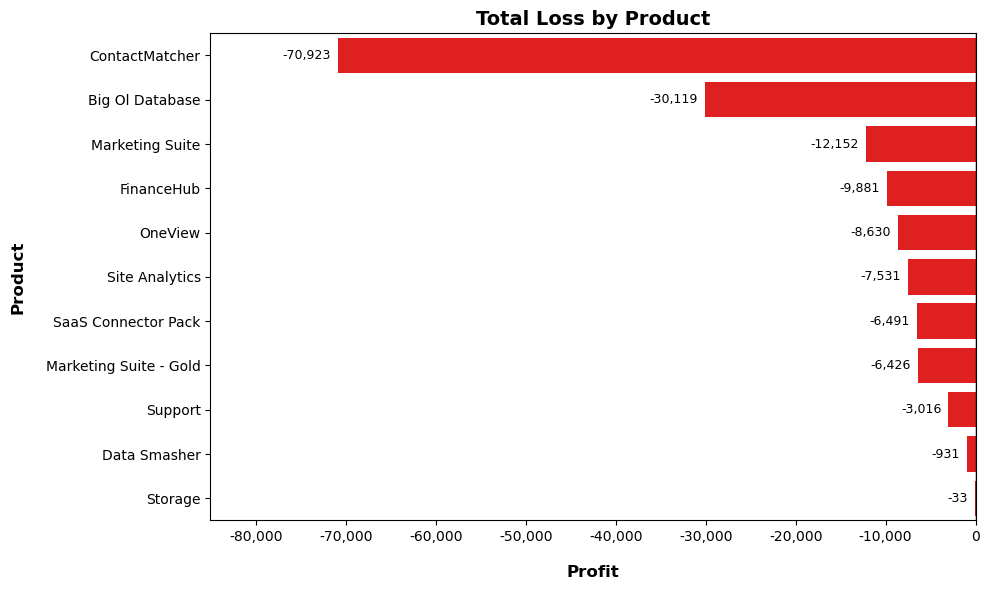

In [65]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=loss_by_product,
    y='Product',
    x='Profit',
    color='red'
)

plt.title(
    'Total Loss by Product',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Product',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Format ribuan
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

# Garis 0
plt.axvline(
    0,
    color='black',
    linewidth=1
)

# Tambah angka
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{v:,.0f}'
            for v in container.datavalues
        ],
        padding=5,
        fontsize=9
    )

# Supaya label angka tidak kepotong
min_profit = loss_by_product['Profit'].min()
max_profit = loss_by_product['Profit'].max()

plt.xlim(
    min_profit*1.20,
    max_profit*1.20 if max_profit > 0 else 0
)

plt.tight_layout()

plt.show()

## Total Loss by Product Insight

- **ContactMatcher** mengalami kerugian terbesar dengan total loss mencapai **-70,923**, jauh lebih tinggi dibanding product lain.
- **Big OI Database** menempati posisi kedua dengan total kerugian **-30,119**.
- Sebagian besar product lain memiliki nilai kerugian yang relatif lebih kecil di bawah **-15,000**.
- Perbedaan loss antar product cukup signifikan, menunjukkan bahwa kerugian perusahaan terkonsentrasi pada beberapa product tertentu.
- Product dengan kerugian terbesar perlu dianalisis lebih lanjut terkait pricing, discount, atau karakteristik transaksi yang menyebabkan loss tinggi.

In [51]:
# Loss by segment
loss_by_segment = loss_transactions.groupby('Segment').agg({
    'Profit': 'sum',
    'Sales': 'sum',
    'Row ID': 'count'
}).reset_index()

loss_by_segment.rename(
    columns={'Row ID':'Loss Transaction Count'},
    inplace=True
)

loss_by_segment = loss_by_segment.sort_values(
    by='Profit',
    ascending=True
)

# Display table (tidak mengubah data asli)
loss_by_segment_display = loss_by_segment.copy()

loss_by_segment_display['Profit'] = (
    loss_by_segment_display['Profit']
    .apply(lambda x: f'{x:,.2f}')
)

loss_by_segment_display['Sales'] = (
    loss_by_segment_display['Sales']
    .apply(lambda x: f'{x:,.2f}')
)

loss_by_segment_display['Loss Transaction Count'] = (
    loss_by_segment_display['Loss Transaction Count']
    .apply(lambda x: f'{x:,.0f}')
)

# nomor urut
loss_by_segment_display = (
    loss_by_segment_display
    .reset_index(drop=True)
)

loss_by_segment_display.index += 1
loss_by_segment_display.index.name='No'

loss_by_segment_display

,Segment,Profit,Sales,Loss Transaction Count
No,,,,
1,SMB,"-84,945.71","247,196.25","1,003"
2,Strategic,"-44,787.21","131,860.54",556
3,Enterprise,"-26,398.37","89,650.37",312


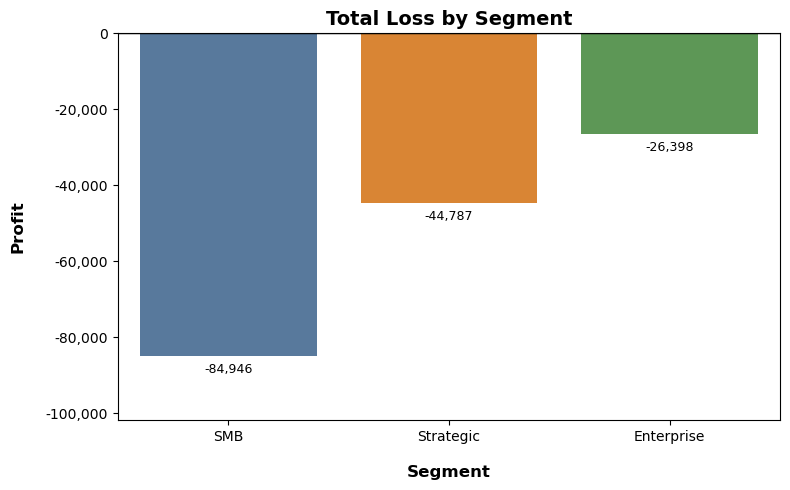

In [67]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=loss_by_segment,
    x='Segment',
    y='Profit',
    palette=['#4C78A8','#F58518','#54A24B']
)

plt.title(
    'Total Loss by Segment',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Segment',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

# Format angka ribuan
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x,pos: f'{x:,.0f}'
    )
)

# Garis 0
plt.axhline(
    0,
    color='black',
    linewidth=1
)

# Tambah angka
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f'{v:,.0f}'
            for v in container.datavalues
        ],
        padding=5,
        fontsize=9
    )

min_profit = loss_by_segment['Profit'].min()
max_profit = loss_by_segment['Profit'].max()

plt.ylim(
    min_profit*1.20,
    max_profit*1.20 if max_profit > 0 else 0
)

plt.tight_layout()
plt.show()

## Total Loss by Segment Insight

- **SMB** mengalami total kerugian terbesar sebesar **-84,946**.
- **Strategic** mencatat kerugian sebesar **-44,787**, sedangkan **Enterprise** memiliki kerugian paling rendah (**-26,398**).
- Meskipun SMB sebelumnya menjadi segmen dengan sales dan profit tertinggi, segmen ini juga menyumbang loss terbesar.
- Hal ini menunjukkan bahwa segmen dengan kontribusi penjualan tinggi belum tentu memiliki risiko kerugian yang rendah.

# 6. Statistical Analysis

Pada tahap ini dilakukan analisis statistik untuk melihat hubungan antara discount dan profitabilitas perusahaan. Analisis ini digunakan untuk memperkuat temuan pada tahap exploratory data analysis, khususnya terkait apakah pemberian discount yang lebih tinggi cenderung berdampak pada penurunan profit.

## 6.1 Correlation Analysis

Analisis korelasi dilakukan untuk melihat hubungan antara variabel numerik utama, yaitu Sales, Quantity, Discount, Profit, dan Profit Margin. Korelasi digunakan untuk mengetahui apakah kenaikan satu variabel cenderung diikuti oleh kenaikan atau penurunan variabel lainnya.

Nilai korelasi berada pada rentang -1 hingga 1. Nilai mendekati 1 menunjukkan hubungan positif, nilai mendekati -1 menunjukkan hubungan negatif, sedangkan nilai mendekati 0 menunjukkan hubungan yang lemah atau tidak linear.

Dalam analisis ini, perhatian utama diberikan pada hubungan antara Discount dengan Profit dan Profit Margin. Jika Discount memiliki korelasi negatif terhadap Profit atau Profit Margin, maka dapat mengindikasikan bahwa semakin tinggi discount yang diberikan, semakin rendah profitabilitas yang dihasilkan.

In [53]:
# Correlation analysis
correlation_data = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin']]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Sales,Quantity,Discount,Profit,Profit Margin
Sales,1.00,0.20,-0.03,0.48,0.00
Quantity,0.20,1.00,0.01,0.07,-0.01
Discount,-0.03,0.01,1.00,-0.22,-0.86
Profit,0.48,0.07,-0.22,1.00,0.22
Profit Margin,0.00,-0.01,-0.86,0.22,1.00


## Correlation Analysis Insight

- **Sales dan Profit** memiliki korelasi positif sedang (**0.48**), menunjukkan bahwa peningkatan sales cenderung diikuti peningkatan profit.
- **Discount dan Profit Margin** memiliki korelasi negatif yang sangat kuat (**-0.86**), menunjukkan bahwa semakin tinggi discount, profit margin cenderung menurun.
- **Discount dan Profit** juga menunjukkan hubungan negatif (**-0.22**), meskipun tidak terlalu kuat.
- **Quantity** memiliki hubungan yang relatif lemah dengan variabel lain, sehingga jumlah produk yang terjual tidak terlalu memengaruhi profit secara langsung.
- Temuan paling penting adalah **discount menjadi faktor yang paling berpengaruh terhadap penurunan profit margin.**

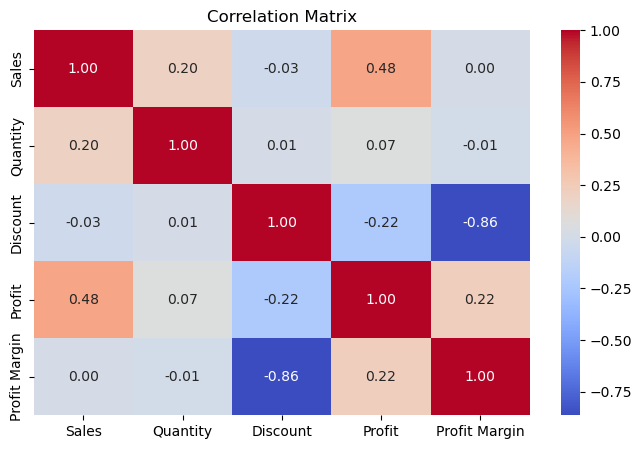

In [54]:
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Correlation Matrix Insight

- Hubungan paling kuat terlihat antara **Discount dan Profit Margin** dengan korelasi **-0.86**, menunjukkan bahwa semakin tinggi discount, profit margin cenderung menurun.
- **Sales dan Profit** memiliki korelasi positif sedang (**0.48**), artinya peningkatan sales cenderung diikuti kenaikan profit.
- **Discount dan Profit** memiliki hubungan negatif (**-0.22**), menunjukkan peningkatan discount berpotensi menekan profit.
- Sebagian besar variabel lain menunjukkan korelasi lemah, sehingga pengaruhnya terhadap profit relatif kecil.

## 6.2 Discount and Profit Relationship

Visualisasi hubungan antara discount dan profit dilakukan untuk melihat pola profit pada setiap tingkat discount. Scatter plot menunjukkan sebaran transaksi berdasarkan discount dan profit, sedangkan bar chart average profit by discount digunakan untuk melihat rata-rata profit pada masing-masing tingkat discount.

Analisis ini penting karena discount merupakan salah satu strategi penjualan yang dapat meningkatkan daya tarik pembelian. Namun, apabila discount terlalu tinggi, perusahaan berpotensi mengalami penurunan profit bahkan kerugian. Oleh karena itu, hubungan antara discount dan profit perlu dianalisis lebih lanjut.

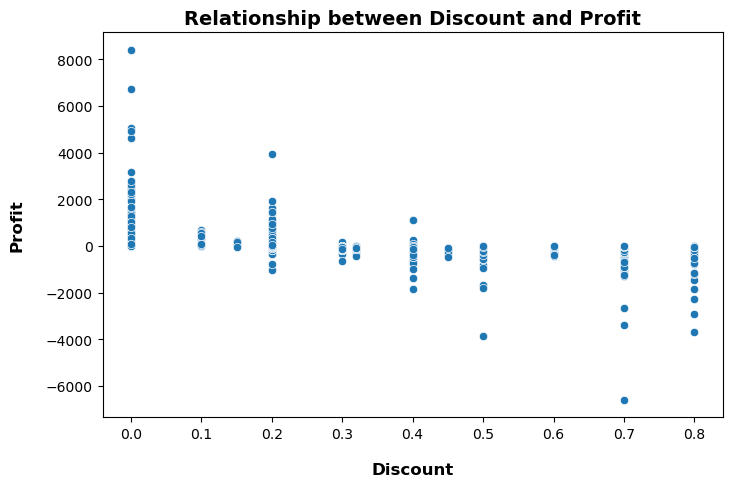

In [55]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title(
    'Relationship between Discount and Profit',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Discount',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.show()

## Discount and Profit Relationship Insight

- Transaksi dengan **discount rendah (0%–20%)** cenderung menghasilkan profit yang lebih tinggi dan lebih bervariasi.
- Pada discount **40%–80%**, semakin banyak transaksi berada di bawah garis profit **0**, yang menunjukkan kerugian.
- Profit terendah terlihat pada discount sekitar **70%**, dengan kerugian mencapai lebih dari **-6,000**.
- Grafik menunjukkan indikasi hubungan negatif antara **discount dan profit**, di mana peningkatan discount cenderung diikuti penurunan profitabilitas.

In [56]:
discount_profit_avg = df.groupby('Discount').agg({
    'Profit': 'mean',
    'Profit Margin': 'mean',
    'Sales': 'mean',
    'Row ID': 'count'
}).reset_index()

discount_profit_avg.rename(columns={'Row ID': 'Transaction Count'}, inplace=True)

discount_profit_avg

,Discount,Profit,Profit Margin,Sales,Transaction Count
0,0.00,66.90,0.34,226.74,4798
1,0.10,96.06,0.16,578.40,94
2,0.15,27.29,0.03,529.97,52
3,0.20,24.70,0.18,209.08,3657
4,0.30,-45.68,-0.12,454.74,227
5,0.32,-88.56,-0.17,536.79,27
6,0.40,-111.93,-0.22,565.13,206
7,0.45,-226.65,-0.45,498.63,11
8,0.50,-310.70,-0.55,892.71,66
9,0.60,-43.08,-0.69,48.15,138


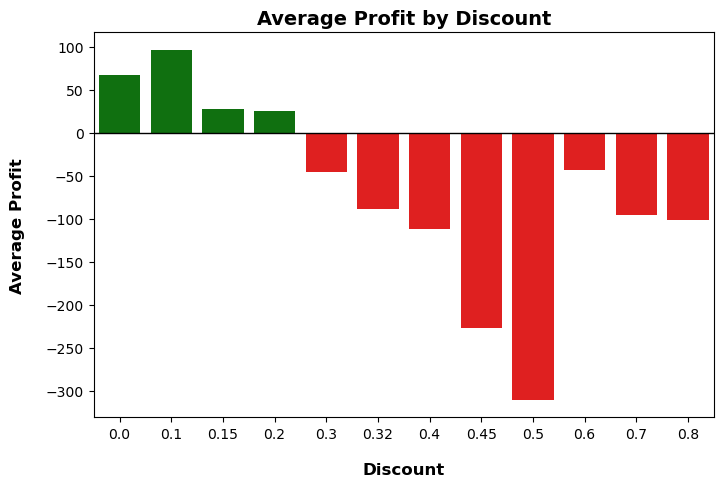

In [57]:
# Warna berdasarkan nilai profit
colors = [
    'green' if x >= 0 else 'red'
    for x in discount_profit_avg['Profit']
]

plt.figure(figsize=(8,5))

sns.barplot(
    data=discount_profit_avg,
    x='Discount',
    y='Profit',
    palette=colors
)

plt.title(
    'Average Profit by Discount',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Discount',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Average Profit',
    fontsize=12,
    fontweight='bold',
    labelpad=15
)

plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.show()

# 6.3 Hypothesis Testing: Profit by Discount Group

Sekarang kita buat uji statistik sederhana.

Logikanya:

- Kita bandingkan profit transaksi tanpa discount/rendah dengan profit transaksi discount tinggi.
- Tujuannya untuk melihat apakah profit pada transaksi discount tinggi berbeda secara signifikan.

In [58]:
# Membuat kategori discount sederhana
df['Discount Group'] = np.where(df['Discount'] <= 0.2, 'Low or No Discount', 'High Discount')

df['Discount Group'].value_counts()

Discount Group
Low or No Discount    8601
High Discount         1393
Name: count, dtype: int64

# Uji Normalitas

Uji normalitas dilakukan untuk mengetahui apakah data profit pada masing-masing kelompok discount berdistribusi normal. Uji ini penting karena pemilihan metode uji statistik bergantung pada karakteristik distribusi data.

Jika p-value lebih kecil dari 0.05, maka data tidak berdistribusi normal. Apabila data tidak normal, maka analisis perbedaan profit antar kelompok discount lebih tepat menggunakan uji non-parametrik seperti Mann-Whitney U Test.

In [59]:
from scipy.stats import shapiro

low_discount_profit = df[df['Discount Group'] == 'Low or No Discount']['Profit']
high_discount_profit = df[df['Discount Group'] == 'High Discount']['Profit']

# Sample maksimal 5000 data untuk Shapiro agar tidak terlalu sensitif
low_sample = low_discount_profit.sample(min(5000, len(low_discount_profit)), random_state=42)
high_sample = high_discount_profit.sample(min(5000, len(high_discount_profit)), random_state=42)

shapiro_low = shapiro(low_sample)
shapiro_high = shapiro(high_sample)

print('Shapiro Test - Low or No Discount:', shapiro_low)
print('Shapiro Test - High Discount:', shapiro_high)

Shapiro Test - Low or No Discount: ShapiroResult(statistic=np.float64(0.19921298060043746), pvalue=np.float64(1.1561940613727372e-90))
Shapiro Test - High Discount: ShapiroResult(statistic=np.float64(0.2896246832878938), pvalue=np.float64(1.8486604998663167e-58))


## Shapiro-Wilk Normality Test Insight

- Kelompok **Low or No Discount** memiliki p-value **< 0.05**, sehingga data profit tidak berdistribusi normal.
- Kelompok **High Discount** juga memiliki p-value **< 0.05**, menunjukkan data profit tidak berdistribusi normal.
- Hasil ini menunjukkan bahwa distribusi profit pada kedua kelompok memiliki pola yang tidak simetris dan dipengaruhi oleh outlier atau nilai ekstrem.
- Karena data tidak memenuhi asumsi normalitas, analisis lanjutan lebih sesuai menggunakan pendekatan **non-parametrik**.

# Mann-Whitney U Test

Uji Mann–Whitney U digunakan karena data profit pada kelompok **Low or No Discount** dan **High Discount** tidak memenuhi asumsi normalitas. Berdasarkan hasil **Shapiro-Wilk Test**, kedua kelompok memiliki **p-value < 0.05**, sehingga distribusi data dinyatakan tidak normal.

Selain itu, hasil Exploratory Data Analysis (EDA) sebelumnya menunjukkan adanya **outlier**, distribusi yang **miring (skewed)**, dan nilai profit ekstrem. Kondisi tersebut dapat memengaruhi hasil uji parametrik seperti **Independent T-Test**, yang mengharuskan data berdistribusi normal.

Mann–Whitney U dipilih karena merupakan metode **non-parametrik** yang tidak mensyaratkan distribusi normal dan lebih robust terhadap outlier. Uji ini digunakan untuk mengetahui apakah terdapat perbedaan profit yang signifikan antara transaksi **Low or No Discount** dan **High Discount**.

Hipotesis yang digunakan adalah:

H0: Tidak terdapat perbedaan profit yang signifikan antara transaksi low or no discount dan high discount.

H1: Terdapat perbedaan profit yang signifikan antara transaksi low or no discount dan high discount.

Kriteria pengambilan keputusan:
- Jika p-value < 0.05, maka H0 ditolak.
- Jika p-value >= 0.05, maka H0 gagal ditolak.

In [60]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    low_discount_profit,
    high_discount_profit,
    alternative='two-sided'
)

print('Mann-Whitney U Statistic:', stat)
print('P-value:', p_value)

Mann-Whitney U Statistic: 11481791.5
P-value: 0.0


## Mann–Whitney U Test Insight

- Hasil Mann–Whitney U Test menunjukkan **p-value < 0.001**, sehingga lebih kecil dari batas signifikansi **0.05**.
- Karena **p-value < 0.05**, maka **H0 ditolak**.
- Terdapat perbedaan profit yang signifikan antara transaksi **Low or No Discount** dan **High Discount**.
- Temuan ini mengindikasikan adanya keterkaitan antara tingkat discount dan profitabilitas transaksi.
- Hasil ini konsisten dengan analisis sebelumnya yang menunjukkan bahwa transaksi dengan discount tinggi cenderung memiliki profit lebih rendah.

## 6.4 Statistical Analysis Summary

Hasil analisis statistik menunjukkan bahwa data profit tidak berdistribusi normal berdasarkan **Shapiro-Wilk Test**, di mana seluruh kelompok memiliki **p-value < 0.05**. Temuan ini mengindikasikan adanya distribusi yang tidak simetris dan dipengaruhi oleh outlier, sehingga analisis lanjutan menggunakan pendekatan non-parametrik lebih sesuai.

Berdasarkan **Mann–Whitney U Test**, diperoleh **p-value < 0.001**, yang menunjukkan adanya perbedaan profit yang signifikan antara transaksi **Low or No Discount** dan **High Discount**. Selain itu, hasil korelasi menunjukkan hubungan negatif yang kuat antara **Discount dan Profit Margin (-0.86)**. Secara keseluruhan, hasil analisis mengindikasikan bahwa discount yang lebih tinggi berkaitan dengan penurunan profitabilitas perusahaan.

# Kesimpulan

Dari analisis yang telah dilakukan, dapat disimpulkan bahwa performa bisnis perusahaan SaaS menunjukkan pertumbuhan yang positif dari tahun ke tahun. Sales meningkat dari **484,247 pada tahun 2020** menjadi **733,947 pada tahun 2023**, sedangkan profit meningkat dari **49,544** menjadi **93,508**. Namun, peningkatan sales dan profit tidak selalu diikuti oleh peningkatan profit margin secara konsisten. Profit margin tertinggi terjadi pada tahun **2022 sebesar 13.43%**, kemudian sedikit menurun menjadi **12.74% pada tahun 2023**. Hal ini menunjukkan bahwa pertumbuhan penjualan perlu tetap dievaluasi dari sisi efisiensi profitabilitas.

Berdasarkan region, **EMEA** menjadi wilayah dengan sales dan profit tertinggi, yaitu sales sebesar **1,043,887** dan profit sebesar **147,456**. Namun, **AMER** memiliki profit margin tertinggi sebesar **15.21%**, sehingga lebih efisien secara profitabilitas. Sebaliknya, **APJ** memiliki profit margin paling rendah, yaitu hanya **2.77%**, meskipun masih menghasilkan sales sebesar **415,464**. Temuan ini menunjukkan bahwa region dengan sales tinggi belum tentu menjadi region dengan efisiensi profit terbaik.

Berdasarkan segment, **SMB** menjadi segment dengan kontribusi sales dan profit tertinggi. Namun, SMB juga mencatat total loss terbesar, yaitu **-84,946**. Artinya, meskipun SMB menjadi segment utama dalam penjualan, segment ini tetap memiliki risiko transaksi rugi yang perlu dievaluasi. Dari sisi industry, **Finance** menjadi industri dengan profit tertinggi sebesar **50,349**, diikuti oleh **Energy** dan **Manufacturing**. Sementara itu, **Transportation** dan **Misc** menjadi industri dengan kontribusi profit paling rendah.

Berdasarkan product, **Alchemy** menjadi produk dengan profit tertinggi, sedangkan **Marketing Suite** menjadi satu-satunya produk dengan profit negatif. Dari sisi sales, **ContactMatcher** mencatat sales tertinggi, tetapi bukan produk dengan profit tertinggi. Bahkan, dalam analisis transaksi loss, ContactMatcher menjadi produk dengan total loss terbesar. Hal ini menunjukkan bahwa sales tinggi tidak selalu mencerminkan profitabilitas yang baik.

Analisis discount menunjukkan bahwa transaksi tanpa discount menghasilkan profit tertinggi, sedangkan kategori **Medium Discount hingga Very High Discount** menghasilkan profit negatif. Hasil korelasi juga menunjukkan hubungan negatif yang sangat kuat antara **Discount dan Profit Margin (-0.86)**. Selain itu, hasil Mann-Whitney U Test menunjukkan **p-value < 0.001**, sehingga terdapat perbedaan profit yang signifikan antara transaksi **Low or No Discount** dan **High Discount**. Secara keseluruhan, temuan ini mengindikasikan bahwa discount yang lebih tinggi berkaitan dengan penurunan profitabilitas perusahaan.

Berdasarkan seluruh temuan tersebut, area bisnis yang paling potensial untuk diprioritaskan adalah **EMEA** dari sisi total profit, **AMER** dari sisi profit margin, segment **SMB** dari sisi kontribusi bisnis, industry **Finance, Energy, dan Manufacturing**, serta product **Alchemy, Site Analytics, dan Data Smasher**. Namun, perusahaan tetap perlu berhati-hati terhadap area dengan risiko loss tinggi, terutama transaksi dengan discount tinggi, segment SMB, dan product ContactMatcher.

## **Rekomendasi**

1. **Batasi pemberian discount tinggi.**  
   Berdasarkan hasil analisis, discount tinggi berkaitan dengan penurunan profit dan profit margin. Oleh karena itu, perusahaan perlu menetapkan batas maksimum discount, terutama pada kategori **Medium Discount hingga Very High Discount** yang pada data ini menghasilkan profit negatif. Pemberian discount tinggi sebaiknya hanya dilakukan pada customer strategis atau transaksi dengan potensi kontrak jangka panjang.

2. **Prioritaskan region dengan profitabilitas tinggi.**  
   **EMEA** dapat diprioritaskan karena memberikan profit tertinggi, sedangkan **AMER** perlu dipertahankan karena memiliki profit margin tertinggi. Untuk **APJ**, perusahaan perlu mengevaluasi strategi penjualan, pricing, dan discount karena profit margin-nya jauh lebih rendah dibanding region lain.

3. **Evaluasi segment SMB secara lebih detail.**  
   **SMB** merupakan segment dengan sales dan profit tertinggi, tetapi juga memiliki total loss terbesar. Perusahaan sebaiknya tidak hanya mengejar volume transaksi dari SMB, tetapi juga mengevaluasi transaksi SMB yang merugikan, terutama dari sisi discount, product yang dibeli, dan karakteristik customer.

4. **Fokuskan strategi sales pada industry yang paling menguntungkan.**  
   **Finance, Energy, dan Manufacturing** dapat menjadi prioritas utama karena memberikan kontribusi profit tertinggi. Perusahaan dapat memperkuat strategi pemasaran, upselling, dan customer relationship pada industri-industri tersebut.

5. **Dorong penjualan product dengan profit tinggi.**  
   Product seperti **Alchemy, Site Analytics, dan Data Smasher** perlu diprioritaskan dalam strategi penjualan karena memberikan profit yang besar. Product dengan sales tinggi tetapi profit tidak sebanding perlu dievaluasi agar perusahaan tidak hanya mengejar revenue, tetapi juga profitabilitas.

6. **Evaluasi product dengan profit negatif dan loss tinggi.**  
   **Marketing Suite** perlu dianalisis lebih lanjut karena menjadi product dengan profit negatif. Selain itu, **ContactMatcher** juga perlu dievaluasi karena meskipun memiliki sales tertinggi, product ini mencatat total loss terbesar pada transaksi loss. Evaluasi dapat dilakukan dari sisi pricing, discount, target customer, dan pola transaksi yang menyebabkan kerugian.

7. **Gunakan profit margin sebagai KPI utama, bukan hanya sales.**  
   Sales tinggi belum tentu menunjukkan performa bisnis yang sehat. Oleh karena itu, perusahaan perlu menjadikan profit margin sebagai salah satu KPI utama dalam mengevaluasi performa **region, segment, industry, dan product**.

8. **Bangun monitoring dashboard untuk sales, profit, discount, dan loss transaction.**  
   Dashboard dapat membantu stakeholder memantau performa bisnis secara lebih cepat. Dashboard sebaiknya mencakup total **sales**, total **profit**, **profit margin**, **discount category**, **top product**, **loss transaction**, serta performa berdasarkan **region, segment, industry, dan product**.

Dengan menerapkan rekomendasi tersebut, perusahaan diharapkan dapat meningkatkan profitabilitas, mengurangi transaksi yang merugikan, serta mengoptimalkan strategi penjualan berdasarkan region, segment, industry, product, dan kebijakan discount yang lebih tepat.